In [1]:
# Setup: imports, device, seeds
import os
import math
import random
import json
from dataclasses import dataclass
from typing import Dict, List, Tuple, Optional

import numpy as np
import pandas as pd

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from tqdm.auto import tqdm

try:
    import timm
except Exception as e:
    raise RuntimeError("Please install timm: pip install timm")

try:
    from sentence_transformers import SentenceTransformer
    SENTENCE_TFORMERS_AVAILABLE = True
except Exception:
    SENTENCE_TFORMERS_AVAILABLE = False

try:
    import faiss  # optional
    FAISS_AVAILABLE = True
except Exception:
    FAISS_AVAILABLE = False

try:
    from sklearn.metrics import f1_score
    SKLEARN_AVAILABLE = True
except Exception:
    SKLEARN_AVAILABLE = False

# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")


/home/saksham/anaconda3/envs/model_training/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Using device: cuda


In [2]:
# Config
ROOT = "/home/saksham/coding/dl"
CSV_PATH = os.path.join(ROOT, "final_dl.csv")
IMAGES_ROOT = ROOT  # image paths in CSV are relative to ROOT

# Train on high-level categories (cookware, electronics, etc.)
# Model will also output fine-grained labels and attributes
CLASSIFICATION_MODE = 'coarse'  # Using coarse-grained training

# Training hyperparams (adjust as needed)
IMG_SIZE = 224
BATCH_SIZE = 64
NUM_WORKERS = 0  # set >0 if numpy/torchvision available in worker processes
EPOCHS = 60  # for quick test; increase for better performance
BASE_LR = 1e-4
WEIGHT_DECAY = 5e-2
WARMUP_EPOCHS = 1
FREEZE_EPOCHS = 2  # freeze early for a few epochs

# Multitask loss weights
LAMBDA_ATTR = 0.5
LAMBDA_CONTR = 0.5
CONTR_TEMPERATURE = 0.07

# Retrieval embedding dimension
PROJ_DIM = 384

# Classification parameters
NUM_CLASSES_TARGET = 10  # Top 10 high-level categories for training
MIN_SAMPLES_PER_CLASS = 5  # Minimum samples per class for stratified split

print({
    "csv": CSV_PATH,
    "num_classes": NUM_CLASSES_TARGET,
    "epochs": EPOCHS,
    "bs": BATCH_SIZE,
    "img": IMG_SIZE,
})


{'csv': '/home/saksham/coding/dl/final_dl.csv', 'num_classes': 10, 'epochs': 60, 'bs': 64, 'img': 224}


In [3]:
# DataFrame loading and vocab building

df = pd.read_csv(CSV_PATH)
if "Unnamed: 5" in df.columns:
    df = df.drop(columns=["Unnamed: 5"])  # empty column

# Absolute image paths
def make_abs_path(rel_path: str) -> str:
    return os.path.join(IMAGES_ROOT, rel_path)

df["abs_path"] = df["image_path"].apply(make_abs_path)

# Extract coarse (high-level) categories for training
def extract_coarse_class(label: str) -> str:
    """Extract high-level category (cookware, electronics, etc.)."""
    if not isinstance(label, str):
        return "unknown"
    label_clean = label.strip().lower().replace("-", "_")
    parts = [p for p in label_clean.split("_") if p]
    if not parts:
        return label_clean or "unknown"
    # handle patterns like "sports item" encoded as sports_item
    if len(parts) >= 2 and parts[0] in {"sports", "home", "daily"} and parts[1] in {"item", "items", "needs"}:
        return f"{parts[0]} {parts[1]}".strip()
    return parts[0]

# Apply coarse extraction for training
print("📦 Training on COARSE categories (cookware, electronics, etc.)")
df["target_class"] = df["class_label"].apply(extract_coarse_class)

# Keep original fine-grained label for prediction/display
df["fine_label"] = df["class_label"].str.strip().str.lower().str.replace("-", "_")

# Select top-K classes by frequency with minimum sample constraint
class_counts = df["target_class"].value_counts()
rare_classes = class_counts[class_counts < 2]
if not rare_classes.empty:
    print("Classes with fewer than 2 samples:")
    for cls_name, count in rare_classes.items():
        print(f"  {cls_name}: {count}")
else:
    print("All classes have at least 2 samples.")

eligible_classes = class_counts[class_counts >= MIN_SAMPLES_PER_CLASS].index.tolist()
if len(eligible_classes) < NUM_CLASSES_TARGET:
    print(f"Warning: only {len(eligible_classes)} classes have >= {MIN_SAMPLES_PER_CLASS} samples; adjusting target count.")
selected_classes = eligible_classes[:NUM_CLASSES_TARGET]
if not selected_classes:
    raise ValueError("No classes meet the minimum sample requirement; please lower MIN_SAMPLES_PER_CLASS or inspect the dataset.")

df = df[df["target_class"].isin(selected_classes)].reset_index(drop=True)
print(f"Selected classes ({len(selected_classes)}):", selected_classes)
print("Filtered dataset size:", len(df))
print("Per-class counts after filtering:\n", df["target_class"].value_counts())

# Parse attributes into dict per row
FACETS = ["color", "material", "condition", "size"]

def parse_attributes(attr_str: str) -> Dict[str, str]:
    values = {k: "unknown" for k in FACETS}
    if isinstance(attr_str, str):
        parts = [p.strip() for p in attr_str.split(";") if p.strip()]
        for p in parts:
            if ":" in p:
                k, v = p.split(":", 1)
                k = k.strip().lower()
                v = v.strip().lower()
                if k in values:
                    values[k] = v if v else "unknown"
    return values

attr_rows = df["attributes"].apply(parse_attributes)

# Build facet vocabularies (include 'unknown')
facet_to_values: Dict[str, List[str]] = {}
for facet in FACETS:
    vals = sorted(set([row[facet] for row in attr_rows]))
    if "unknown" not in vals:
        vals = ["unknown"] + vals
    facet_to_values[facet] = vals

# Class label maps
# Coarse classes (for stratified split and primary classification)
coarse_classes = sorted(set(df["target_class"]))
coarse_to_id = {c: i for i, c in enumerate(coarse_classes)}
id_to_coarse = {i: c for c, i in coarse_to_id.items()}

# Fine-grained classes (all unique fine labels)
fine_classes = sorted(set(df["fine_label"]))
fine_to_id = {c: i for i, c in enumerate(fine_classes)}
id_to_fine = {i: c for c, i in fine_to_id.items()}

print(f"Coarse classes: {len(coarse_classes)}")
print(f"Fine-grained classes: {len(fine_classes)}")

from pathlib import Path
DATASET_TAG = f"{Path(CSV_PATH).stem}_{len(df)}_{len(coarse_classes)}c_{len(fine_classes)}f"
print("Checkpoint dataset tag:", DATASET_TAG)
# Keep backward compatibility
classes = coarse_classes
cls_to_id = coarse_to_id
id_to_cls = id_to_coarse

# Facet value maps
facet_to_id: Dict[str, Dict[str, int]] = {
    facet: {v: i for i, v in enumerate(values)} for facet, values in facet_to_values.items()
}
id_to_facet_value: Dict[str, Dict[int, str]] = {
    facet: {i: v for v, i in mapping.items()} for facet, mapping in facet_to_id.items()
}

print("Facet vocab sizes:")
for facet in FACETS:
    print(f"  {facet}: {len(facet_to_values[facet])} values -> {facet_to_values[facet]}")

# ========================================
# UNIFIED ATTRIBUTE APPROACH
# Treat class labels as additional attributes
# ========================================
print("\n" + "="*60)
print("🔄 UNIFIED ATTRIBUTE APPROACH")
print("   Treating class labels as attributes")
print("="*60)

# Extended facets including class labels
FACETS_UNIFIED = ["coarse_class", "fine_class", "color", "material", "condition", "size"]

# Build unified facet vocabularies
facet_to_values_unified: Dict[str, List[str]] = {
    "coarse_class": coarse_classes,
    "fine_class": fine_classes,
    "color": facet_to_values["color"],
    "material": facet_to_values["material"],
    "condition": facet_to_values["condition"],
    "size": facet_to_values["size"]
}

facet_to_id_unified: Dict[str, Dict[str, int]] = {
    facet: {v: i for i, v in enumerate(values)} 
    for facet, values in facet_to_values_unified.items()
}

id_to_facet_value_unified: Dict[str, Dict[int, str]] = {
    facet: {i: v for v, i in mapping.items()} 
    for facet, mapping in facet_to_id_unified.items()
}

print("\nUnified facet vocab sizes:")
for facet in FACETS_UNIFIED:
    print(f"  {facet}: {len(facet_to_values_unified[facet])} values")
print("="*60)

# ========================================
# HIERARCHICAL MAPPING: Coarse -> Fine Classes
# ========================================
print("\n🔗 Building hierarchical class mapping...")

# Build mapping from coarse class to valid fine classes
coarse_to_fine_mapping: Dict[str, List[str]] = {}
for coarse_class in coarse_classes:
    # Get all fine classes that belong to this coarse class
    fine_in_coarse = df[df["target_class"] == coarse_class]["fine_label"].unique().tolist()
    coarse_to_fine_mapping[coarse_class] = sorted(fine_in_coarse)

print("\nHierarchical class structure:")
for coarse, fines in coarse_to_fine_mapping.items():
    print(f"  {coarse}: {len(fines)} fine classes")
    if len(fines) <= 5:
        print(f"    → {fines}")
    else:
        print(f"    → {fines[:3]} ... (+{len(fines)-3} more)")

# Create mapping from coarse_id to valid fine_ids
coarse_id_to_fine_ids: Dict[int, List[int]] = {}
for coarse_class, coarse_id in coarse_to_id.items():
    fine_classes_list = coarse_to_fine_mapping[coarse_class]
    fine_ids_list = [facet_to_id_unified["fine_class"][fc] for fc in fine_classes_list]
    coarse_id_to_fine_ids[coarse_id] = fine_ids_list

print("\n✅ Hierarchical mapping created!")
print("="*60)


📦 Training on COARSE categories (cookware, electronics, etc.)
All classes have at least 2 samples.
Selected classes (10): ['cookware', 'tableware', 'cleaning', 'clothing', 'electronic', 'footwear', 'personal', 'sports', 'travel', 'stationery']
Filtered dataset size: 628
Per-class counts after filtering:
 target_class
cookware      79
tableware     70
cleaning      60
clothing      60
electronic    60
footwear      60
personal      60
sports        60
travel        60
stationery    59
Name: count, dtype: int64
Coarse classes: 10
Fine-grained classes: 126
Checkpoint dataset tag: final_dl_628_10c_126f
Facet vocab sizes:
  color: 15 values -> ['unknown', 'black', 'blue', 'brown', 'green', 'grey', 'maroon', 'orange', 'pink', 'purple', 'red', 'silver', 'transparent', 'white', 'yellow']
  material: 16 values -> ['unknown', 'ceramic', 'cloth', 'cotton', 'fabric', 'glass', 'leather', 'metal', 'paper', 'plastic', 'polyester', 'rubber', 'sponge', 'synthetic', 'wood', 'wooden']
  condition: 3 valu

In [4]:
# Losses, optimizer, and utilities

def cosine_warmup_lr(epoch, base_lr, warmup_epochs, total_epochs):
    if epoch < warmup_epochs:
        return base_lr * float(epoch + 1) / float(warmup_epochs)
    progress = (epoch - warmup_epochs) / max(1, total_epochs - warmup_epochs)
    return base_lr * 0.5 * (1 + math.cos(math.pi * progress))


def compute_losses(logits_coarse, coarse_targets, logits_fine, fine_targets, logits_attrs: Dict[str, torch.Tensor], facet_targets: Dict[str, torch.Tensor]):
    loss_coarse = F.cross_entropy(logits_coarse, coarse_targets)
    loss_fine = F.cross_entropy(logits_fine, fine_targets)
    loss_attr = 0.0
    for facet, logits in logits_attrs.items():
        loss_attr = loss_attr + F.cross_entropy(logits, facet_targets[facet])
    loss_attr = loss_attr / max(1, len(logits_attrs))
    return loss_coarse, loss_fine, loss_attr


def contrastive_loss(img_emb: torch.Tensor, txt_emb: torch.Tensor, temperature: float = 0.07):
    img_emb = F.normalize(img_emb, dim=-1)
    txt_emb = F.normalize(txt_emb, dim=-1)
    logits = img_emb @ txt_emb.t() / temperature  # [B, B]
    targets = torch.arange(img_emb.size(0), device=img_emb.device)
    loss_i2t = F.cross_entropy(logits, targets)
    loss_t2i = F.cross_entropy(logits.t(), targets)
    return (loss_i2t + loss_t2i) * 0.5


# Optimizer
# Optimizer (legacy multi-head; only if `model` exists)
if 'model' in globals():
    optimizer = torch.optim.AdamW(model.parameters(), lr=BASE_LR, weight_decay=WEIGHT_DECAY)
    scaler = torch.cuda.amp.GradScaler(enabled=(device.type == 'cuda'))
    frozen = False
else:
    # Unified models use optimizer_unified / optimizer_unified_tinyvit elsewhere
    optimizer = None
    scaler = None
    frozen = False


def set_backbone_trainable(module: nn.Module, trainable: bool):
    for p in module.parameters():
        p.requires_grad = trainable

# Metrics
@torch.no_grad()
def accuracy(pred: torch.Tensor, target: torch.Tensor) -> float:
    pred_labels = pred.argmax(dim=1)
    return (pred_labels == target).float().mean().item()

@torch.no_grad()
def macro_f1(pred: torch.Tensor, target: torch.Tensor) -> float:
    if not SKLEARN_AVAILABLE:
        return accuracy(pred, target)
    y_true = target.cpu().numpy()
    y_pred = pred.argmax(dim=1).cpu().numpy()
    return float(f1_score(y_true, y_pred, average='macro'))


In [5]:
# Dataset and transforms
from PIL import Image
from torchvision import transforms

train_transforms = transforms.Compose([
    transforms.RandomResizedCrop(IMG_SIZE, scale=(0.7, 1.0)),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(0.2, 0.2, 0.2, 0.1),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

val_transforms = transforms.Compose([
    transforms.Resize(IMG_SIZE + 32),
    transforms.CenterCrop(IMG_SIZE),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

class MultiTaskDataset(Dataset):
    def __init__(self, frame: pd.DataFrame, facet_to_id: Dict[str, Dict[str, int]], cls_to_id: Dict[str, int], fine_to_id: Dict[str, int], transform=None):
        self.frame = frame.reset_index(drop=True)
        self.facet_to_id = facet_to_id
        self.cls_to_id = cls_to_id
        self.fine_to_id = fine_to_id
        self.transform = transform

    def __len__(self) -> int:
        return len(self.frame)

    def __getitem__(self, idx: int):
        row = self.frame.iloc[idx]
        image = Image.open(row["abs_path"]).convert("RGB")
        if self.transform is not None:
            image = self.transform(image)
        coarse_id = self.cls_to_id[row["target_class"]]
        fine_id = self.fine_to_id[row["fine_label"]]
        attrs = parse_attributes(row["attributes"])
        facet_ids = {facet: self.facet_to_id[facet][attrs.get(facet, "unknown")] for facet in FACETS}
        caption = row.get("caption", "")
        return image, coarse_id, fine_id, facet_ids, caption, row.get("instance_id", "")

# Custom collate function to properly handle dictionary of facet_ids
def collate_multitask(batch):
    images = torch.stack([item[0] for item in batch])
    coarse_ids = [item[1] for item in batch]
    fine_ids = [item[2] for item in batch]
    facet_ids = [item[3] for item in batch]  # list of dicts
    captions = [item[4] for item in batch]
    inst_ids = [item[5] for item in batch]
    return images, coarse_ids, fine_ids, facet_ids, captions, inst_ids

# Train/Val/Test split (stratified by coarse class)
from sklearn.model_selection import train_test_split

train_df, temp_df = train_test_split(df, test_size=0.3, random_state=SEED, stratify=df["target_class"])
val_df, test_df = train_test_split(temp_df, test_size=0.5, random_state=SEED, stratify=temp_df["target_class"])

train_set = MultiTaskDataset(train_df, facet_to_id, cls_to_id, fine_to_id, transform=train_transforms)
val_set = MultiTaskDataset(val_df, facet_to_id, cls_to_id, fine_to_id, transform=val_transforms)
test_set = MultiTaskDataset(test_df, facet_to_id, cls_to_id, fine_to_id, transform=val_transforms)

train_loader = DataLoader(train_set, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS, pin_memory=True, collate_fn=collate_multitask)
val_loader = DataLoader(val_set, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True, collate_fn=collate_multitask)
test_loader = DataLoader(test_set, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True, collate_fn=collate_multitask)

print(f"DataLoaders created with num_workers={NUM_WORKERS}")
print(f"Dataset sizes: train={len(train_set)}, val={len(val_set)}, test={len(test_set)}")
len(train_set), len(val_set), len(test_set)


DataLoaders created with num_workers=0
Dataset sizes: train=439, val=94, test=95


(439, 94, 95)

In [6]:
# ========================================
# UNIFIED ATTRIBUTE MODEL - Classes as Attributes
# ========================================

# Dataset for unified approach
class UnifiedAttributeDataset(Dataset):
    def __init__(self, frame: pd.DataFrame, facet_to_id_unified: Dict[str, Dict[str, int]], transform=None):
        self.frame = frame.reset_index(drop=True)
        self.facet_to_id = facet_to_id_unified
        self.transform = transform

    def __len__(self) -> int:
        return len(self.frame)

    def __getitem__(self, idx: int):
        row = self.frame.iloc[idx]
        image = Image.open(row["abs_path"]).convert("RGB")
        if self.transform is not None:
            image = self.transform(image)
        
        # Parse all attributes including class labels
        attrs = parse_attributes(row["attributes"])
        facet_ids = {
            "coarse_class": self.facet_to_id["coarse_class"][row["target_class"]],
            "fine_class": self.facet_to_id["fine_class"][row["fine_label"]],
            "color": self.facet_to_id["color"][attrs.get("color", "unknown")],
            "material": self.facet_to_id["material"][attrs.get("material", "unknown")],
            "condition": self.facet_to_id["condition"][attrs.get("condition", "unknown")],
            "size": self.facet_to_id["size"][attrs.get("size", "unknown")]
        }
        
        caption = row.get("caption", "")
        return image, facet_ids, caption, row.get("instance_id", "")

# Collate function for unified approach
def collate_unified(batch):
    images = torch.stack([item[0] for item in batch])
    facet_ids = [item[1] for item in batch]  # list of dicts
    captions = [item[2] for item in batch]
    inst_ids = [item[3] for item in batch]
    return images, facet_ids, captions, inst_ids

# Create unified datasets
train_set_unified = UnifiedAttributeDataset(train_df, facet_to_id_unified, transform=train_transforms)
val_set_unified = UnifiedAttributeDataset(val_df, facet_to_id_unified, transform=val_transforms)
test_set_unified = UnifiedAttributeDataset(test_df, facet_to_id_unified, transform=val_transforms)

train_loader_unified = DataLoader(train_set_unified, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS, pin_memory=True, collate_fn=collate_unified)
val_loader_unified = DataLoader(val_set_unified, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True, collate_fn=collate_unified)
test_loader_unified = DataLoader(test_set_unified, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True, collate_fn=collate_unified)

print(f"✅ Unified DataLoaders created")
print(f"   Dataset sizes: train={len(train_set_unified)}, val={len(val_set_unified)}, test={len(test_set_unified)}")


✅ Unified DataLoaders created
   Dataset sizes: train=439, val=94, test=95


In [7]:
# Unified Attribute Model - Only attribute heads, no separate classification
class UnifiedAttributeModel(nn.Module):
    def __init__(self, backbone_name: str, facet_to_id: Dict[str, Dict[str, int]], proj_dim: int = 384):
        super().__init__()
        self.backbone_name = backbone_name
        
        # Create backbone
        self.backbone = timm.create_model(backbone_name, pretrained=True, num_classes=0, global_pool='avg')
        embed_dim = getattr(self.backbone, 'num_features', 192)
        self.embed_dim = embed_dim
        self.proj_dim = proj_dim

        # Only attribute heads - treating classes as attributes
        self.attr_heads = nn.ModuleDict({})
        for facet, mapping in facet_to_id.items():
            self.attr_heads[facet] = nn.Linear(embed_dim, len(mapping))

        # Image projection for retrieval
        self.img_proj = nn.Sequential(
            nn.Linear(embed_dim, proj_dim),
            nn.ReLU(inplace=True),
            nn.Linear(proj_dim, proj_dim)
        )

    def forward(self, x: torch.Tensor):
        feats = self.backbone(x)
        logits_attrs = {facet: head(feats) for facet, head in self.attr_heads.items()}
        img_emb = self.img_proj(feats)
        img_emb = F.normalize(img_emb, dim=-1)
        return feats, logits_attrs, img_emb

# Create unified model
model_unified = UnifiedAttributeModel(
    backbone_name='deit_tiny_patch16_224',
    facet_to_id=facet_to_id_unified,
    proj_dim=PROJ_DIM
).to(device)

print(f"✅ Unified model created")
print(f"   Backbone: DeiT-Tiny")
print(f"   Embed dim: {model_unified.embed_dim}")
print(f"   Attribute heads: {len(model_unified.attr_heads)}")
print(f"   Head sizes: ", {k: v.out_features for k, v in model_unified.attr_heads.items()})


Unexpected keys (norm.bias, norm.weight) found while loading pretrained weights. This may be expected if model is being adapted.


✅ Unified model created
   Backbone: DeiT-Tiny
   Embed dim: 192
   Attribute heads: 6
   Head sizes:  {'coarse_class': 10, 'fine_class': 126, 'color': 15, 'material': 16, 'condition': 3, 'size': 4}


In [8]:
# Training and evaluation for unified approach

# Optimizer for unified model
optimizer_unified = torch.optim.AdamW(model_unified.parameters(), lr=BASE_LR, weight_decay=WEIGHT_DECAY)
scaler_unified = torch.cuda.amp.GradScaler(enabled=(device.type == 'cuda'))

@torch.no_grad()
def evaluate_unified(model: nn.Module, loader: DataLoader, facet_list: List[str], use_hierarchy: bool = True) -> Dict[str, float]:
    """Evaluate unified model treating classes as attributes."""
    model.eval()
    facet_accs = {facet: [] for facet in facet_list}
    facet_f1s = {facet: [] for facet in facet_list}
    fine_hier_accs = []  # Fine class accuracy with hierarchical constraint
    
    for images, facet_ids, captions, _ in loader:
        images = images.to(device, non_blocking=True)
        facet_batch = {f: torch.as_tensor([d[f] for d in facet_ids], device=device) for f in facet_list}
        
        with torch.cuda.amp.autocast(enabled=(device.type=='cuda')):
            _, logits_attrs, _ = model(images)
        
        # Evaluate all facets normally
        for f in facet_list:
            facet_accs[f].append(accuracy(logits_attrs[f], facet_batch[f]))
            facet_f1s[f].append(macro_f1(logits_attrs[f], facet_batch[f]))
        
        # Evaluate fine class with hierarchical constraint
        if use_hierarchy:
            coarse_preds = logits_attrs["coarse_class"].argmax(dim=1)
            fine_probs = torch.softmax(logits_attrs["fine_class"], dim=1)
            fine_targets = facet_batch["fine_class"]
            
            correct = 0
            for i in range(len(coarse_preds)):
                coarse_id = coarse_preds[i].item()
                
                if coarse_id in coarse_id_to_fine_ids:
                    valid_fine_ids = coarse_id_to_fine_ids[coarse_id]
                    
                    # Mask and renormalize
                    masked_probs = torch.zeros_like(fine_probs[i])
                    masked_probs[valid_fine_ids] = fine_probs[i][valid_fine_ids]
                    
                    if masked_probs.sum() > 0:
                        fine_pred = masked_probs.argmax().item()
                    else:
                        fine_pred = fine_probs[i].argmax().item()
                else:
                    fine_pred = fine_probs[i].argmax().item()
                
                if fine_pred == fine_targets[i].item():
                    correct += 1
            
            fine_hier_accs.append(correct / len(coarse_preds))
    
    out = {}
    for f in facet_list:
        out[f'{f}_acc'] = float(np.mean(facet_accs[f])) if facet_accs[f] else 0.0
        out[f'{f}_f1'] = float(np.mean(facet_f1s[f])) if facet_f1s[f] else 0.0
    
    # Add hierarchical fine class accuracy
    if use_hierarchy and fine_hier_accs:
        out['fine_class_acc_hier'] = float(np.mean(fine_hier_accs))
    
    # Overall average
    all_accs = [out[f'{f}_acc'] for f in facet_list]
    out['avg_acc'] = float(np.mean(all_accs))
    
    return out

def hierarchical_consistency_loss(coarse_logits: torch.Tensor, fine_logits: torch.Tensor, 
                                   coarse_targets: torch.Tensor, fine_targets: torch.Tensor) -> torch.Tensor:
    """
    Compute hierarchical consistency loss.
    Encourages the model to only predict fine classes that are valid for the coarse class.
    """
    batch_size = coarse_logits.size(0)
    fine_probs = torch.softmax(fine_logits, dim=1)
    
    # Create a mask for valid fine classes given coarse class
    valid_mask = torch.zeros_like(fine_probs)
    
    for i in range(batch_size):
        coarse_id = coarse_targets[i].item()
        if coarse_id in coarse_id_to_fine_ids:
            valid_fine_ids = coarse_id_to_fine_ids[coarse_id]
            valid_mask[i, valid_fine_ids] = 1.0
    
    # Penalize probability mass on invalid fine classes
    invalid_prob_mass = (fine_probs * (1 - valid_mask)).sum(dim=1).mean()
    
    return invalid_prob_mass


def train_unified(model: nn.Module, train_loader: DataLoader, val_loader: DataLoader, 
                  optimizer, scaler, epochs: int = EPOCHS, model_name: str = "unified_model",
                  use_contrastive: bool = True, use_hierarchical_loss: bool = True):
    """Train unified model."""
    frozen = False
    best_val_avg_acc = 0.0
    
    for epoch in range(epochs):
        model.train()
        
        # Freeze/unfreeze strategy
        if (epoch < FREEZE_EPOCHS) and not frozen:
            set_backbone_trainable(model.backbone, False)
            for n, m in model.backbone.named_modules():
                if 'blocks' in n or 'fc' in n or 'head' in n:
                    set_backbone_trainable(m, True)
            for p in model.attr_heads.parameters(): p.requires_grad = True
            for p in model.img_proj.parameters(): p.requires_grad = True
        elif (epoch == FREEZE_EPOCHS) and not frozen:
            set_backbone_trainable(model.backbone, True)
            frozen = True

        # Adjust LR
        lr = cosine_warmup_lr(epoch, BASE_LR, WARMUP_EPOCHS, epochs)
        for g in optimizer.param_groups:
            g['lr'] = lr

        running = {"loss": 0.0, "loss_attr": 0.0, "loss_ctr": 0.0, "loss_hier": 0.0}
        prog_bar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs}", leave=False)
        
        for images, facet_ids, captions, _ in prog_bar:
            images = images.to(device, non_blocking=True)
            facet_batch = {f: torch.as_tensor([d[f] for d in facet_ids], device=device) for f in FACETS_UNIFIED}

            with torch.cuda.amp.autocast(enabled=(device.type=='cuda')):
                _, logits_attrs, img_emb = model(images)
                
                # All attributes have equal weight
                loss_attr = 0.0
                for facet, logits in logits_attrs.items():
                    loss_attr = loss_attr + F.cross_entropy(logits, facet_batch[facet])
                loss_attr = loss_attr / len(logits_attrs)
                
                # Hierarchical consistency loss
                if use_hierarchical_loss:
                    loss_hier = hierarchical_consistency_loss(
                        logits_attrs["coarse_class"],
                        logits_attrs["fine_class"],
                        facet_batch["coarse_class"],
                        facet_batch["fine_class"]
                    )
                else:
                    loss_hier = torch.tensor(0.0, device=device)
                
                # Contrastive loss
                if use_contrastive and text_encoder is not None:
                    txt_emb = text_encoder.encode(list(captions))
                    loss_ctr = contrastive_loss(img_emb, txt_emb, temperature=CONTR_TEMPERATURE)
                else:
                    loss_ctr = torch.tensor(0.0, device=device)
                
                # Total loss
                loss = loss_attr + 0.5 * loss_hier + LAMBDA_CONTR * loss_ctr

            optimizer.zero_grad(set_to_none=True)
            scaler.scale(loss).backward()
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            scaler.step(optimizer)
            scaler.update()

            running["loss"] += loss.item()
            running["loss_attr"] += loss_attr.item()
            running["loss_ctr"] += float(loss_ctr.item())
            running["loss_hier"] += float(loss_hier.item())

            prog_bar.set_postfix({
                "loss": f"{loss.item():.4f}",
                "attr": f"{loss_attr.item():.4f}",
                "hier": f"{float(loss_hier.item()):.4f}",
                "ctr": f"{float(loss_ctr.item()):.4f}",
            })

        n_batches = max(1, len(train_loader))
        log = {k: v / n_batches for k, v in running.items()}
        val_metrics = evaluate_unified(model, val_loader, FACETS_UNIFIED, use_hierarchy=use_hierarchical_loss)
        
        print(f"Epoch {epoch+1:03d}/{epochs} LR {lr:.2e} | ", end="")
        print("train:", {k: round(v, 4) for k, v in log.items()})
        
        fine_acc_str = f"fine={val_metrics['fine_class_acc']:.4f}"
        if 'fine_class_acc_hier' in val_metrics:
            fine_acc_str += f"(hier={val_metrics['fine_class_acc_hier']:.4f})"
        
        print(f"  val: coarse={val_metrics['coarse_class_acc']:.4f} {fine_acc_str} " +
              f"color={val_metrics['color_acc']:.4f} material={val_metrics['material_acc']:.4f} " +
              f"avg={val_metrics['avg_acc']:.4f}")

        # Save if best
        if val_metrics['avg_acc'] > best_val_avg_acc:
            best_val_avg_acc = val_metrics['avg_acc']
            save_checkpoint(model, optimizer, epoch+1, val_metrics, model_name=model_name, best=True,dataset_tag=DATASET_TAG)
    
    print(f"\n✅ Training complete! Best avg val acc: {best_val_avg_acc:.4f}")
    return model

print("✅ Training functions ready for unified model")


✅ Training functions ready for unified model


/tmp/ipykernel_20358/2698944262.py:5: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler_unified = torch.cuda.amp.GradScaler(enabled=(device.type == 'cuda'))


In [9]:
# ✅ Dataset-scoped checkpoint helpers
from pathlib import Path

if 'CHECKPOINT_DIR' not in globals():
    CHECKPOINT_DIR = os.path.join(ROOT, 'checkpoints')

def _ckpt_subdir(dataset_tag: str) -> str:
    sub = os.path.join(CHECKPOINT_DIR, dataset_tag)
    Path(sub).mkdir(parents=True, exist_ok=True)
    return sub

def save_checkpoint(model, optimizer, epoch, metrics, model_name="model", best=False, dataset_tag: str = None):
    dataset_tag = dataset_tag or globals().get('DATASET_TAG', 'default')
    subdir = _ckpt_subdir(dataset_tag)
    checkpoint = {
        'epoch': epoch,
        'model_state_dict': model.state_dict(),
        'optimizer_state_dict': optimizer.state_dict() if optimizer is not None else None,
        'metrics': metrics,
        'model_config': {
            'backbone_name': getattr(model, 'backbone_name', None),
            'embed_dim': getattr(model, 'embed_dim', None),
            'proj_dim': getattr(model, 'proj_dim', None),
            'dataset_tag': dataset_tag,
            'model_name': model_name,
        }
    }
    path = os.path.join(subdir, f"{model_name}_best.pt" if best else f"{model_name}_epoch_{epoch}.pt")
    torch.save(checkpoint, path)
    if best:
        print(f"💾 Saved best to {path}")
    return path

def load_checkpoint(model, optimizer=None, model_name="model", dataset_tag: str = None):
    dataset_tag = dataset_tag or globals().get('DATASET_TAG', 'default')
    subdir = _ckpt_subdir(dataset_tag)
    best_path = os.path.join(subdir, f"{model_name}_best.pt")
    if os.path.exists(best_path):
        print(f"📂 Loading checkpoint from {best_path}")
        checkpoint = torch.load(best_path, map_location=device)
        model.load_state_dict(checkpoint['model_state_dict'])
        if optimizer is not None and checkpoint.get('optimizer_state_dict') is not None:
            optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
        print(f"✅ Loaded epoch {checkpoint.get('epoch')} | metrics: {checkpoint.get('metrics')}")
        return True, checkpoint.get('epoch', 0), checkpoint.get('metrics', {})
    print(f"❌ No checkpoint at {best_path}")
    return False, 0, {}

def checkpoint_exists(model_name="model", dataset_tag: str = None):
    dataset_tag = dataset_tag or globals().get('DATASET_TAG', 'default')
    subdir = _ckpt_subdir(dataset_tag)
    return os.path.exists(os.path.join(subdir, f"{model_name}_best.pt"))

print(f"Checkpoint root: {CHECKPOINT_DIR} | dataset tag: {globals().get('DATASET_TAG','default')}")

Checkpoint root: /home/saksham/coding/dl/checkpoints | dataset tag: final_dl_628_10c_126f


In [10]:
# 🏋️ Load Unified DeiT Model (Classes as Attributes)

CHECKPOINT_PATH_UNIFIED = "/home/saksham/coding/dl/checkpoints/final_dl_628_10c_126f/deit_unified_attr_best.pt"

print(f"📝 Loading model from: {CHECKPOINT_PATH_UNIFIED}")

# Create model and optimizer
model_unified = UnifiedAttributeModel(
    backbone_name='deit_tiny_patch16_224',
    facet_to_id=facet_to_id_unified,
    proj_dim=PROJ_DIM
).to(device)

optimizer_unified = torch.optim.AdamW(model_unified.parameters(), lr=BASE_LR, weight_decay=WEIGHT_DECAY)
scaler_unified = torch.cuda.amp.GradScaler(enabled=(device.type == 'cuda'))

# Load checkpoint
checkpoint = torch.load(CHECKPOINT_PATH_UNIFIED, map_location=device)
model_unified.load_state_dict(checkpoint['model_state_dict'])
if checkpoint.get('optimizer_state_dict') is not None:
    optimizer_unified.load_state_dict(checkpoint['optimizer_state_dict'])

print(f"✅ Loaded checkpoint from epoch {checkpoint.get('epoch')}")
print(f"   Metrics: {checkpoint.get('metrics')}")


📝 Loading model from: /home/saksham/coding/dl/checkpoints/final_dl_628_10c_126f/deit_unified_attr_best.pt


Unexpected keys (norm.bias, norm.weight) found while loading pretrained weights. This may be expected if model is being adapted.


✅ Loaded checkpoint from epoch 49
   Metrics: {'coarse_class_acc': 0.9041666984558105, 'coarse_class_f1': 0.9079569613393143, 'fine_class_acc': 0.6145833432674408, 'fine_class_f1': 0.47232492997198877, 'color_acc': 0.8531250357627869, 'color_f1': 0.7061381990329358, 'material_acc': 0.8229166865348816, 'material_f1': 0.7641290721473648, 'condition_acc': 0.9276041984558105, 'condition_f1': 0.8692120814645568, 'size_acc': 0.8619791865348816, 'size_f1': 0.7562934577859951, 'fine_class_acc_hier': 0.5989583333333333, 'avg_acc': 0.8307291915019354}


/tmp/ipykernel_20358/4181644397.py:15: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler_unified = torch.cuda.amp.GradScaler(enabled=(device.type == 'cuda'))


In [11]:
# Helpers required by evaluate_unified
try:
    from sklearn.metrics import f1_score
    SKLEARN_AVAILABLE = True
except Exception:
    SKLEARN_AVAILABLE = False

@torch.no_grad()
def accuracy(pred: torch.Tensor, target: torch.Tensor) -> float:
    return (pred.argmax(dim=1) == target).float().mean().item()

@torch.no_grad()
def macro_f1(pred: torch.Tensor, target: torch.Tensor) -> float:
    if not SKLEARN_AVAILABLE:
        return accuracy(pred, target)
    y_true = target.detach().cpu().numpy()
    y_pred = pred.argmax(dim=1).detach().cpu().numpy()
    return float(f1_score(y_true, y_pred, average='macro'))

In [12]:
# Evaluate unified model on test set
test_metrics_unified = evaluate_unified(model_unified, test_loader_unified, FACETS_UNIFIED, use_hierarchy=True)

print("\n" + "="*70)
print("📊 UNIFIED MODEL TEST RESULTS (Classes as Attributes)")
print("="*70)
print(f"\n🎯 Classification Performance:")
print(f"   Coarse Class Accuracy: {test_metrics_unified['coarse_class_acc']:.4f}")
print(f"   Coarse Class F1:       {test_metrics_unified['coarse_class_f1']:.4f}")
print(f"   Fine Class Accuracy:   {test_metrics_unified['fine_class_acc']:.4f}")
print(f"   Fine Class F1:         {test_metrics_unified['fine_class_f1']:.4f}")
if 'fine_class_acc_hier' in test_metrics_unified:
    print(f"   Fine Class (Hierarchical): {test_metrics_unified['fine_class_acc_hier']:.4f} ⭐")

print(f"\n🏷️  Attribute Performance:")
print(f"   Color Accuracy:        {test_metrics_unified['color_acc']:.4f}  (F1: {test_metrics_unified['color_f1']:.4f})")
print(f"   Material Accuracy:     {test_metrics_unified['material_acc']:.4f}  (F1: {test_metrics_unified['material_f1']:.4f})")
print(f"   Condition Accuracy:    {test_metrics_unified['condition_acc']:.4f}  (F1: {test_metrics_unified['condition_f1']:.4f})")
print(f"   Size Accuracy:         {test_metrics_unified['size_acc']:.4f}  (F1: {test_metrics_unified['size_f1']:.4f})")

print(f"\n⭐ Overall Average Accuracy: {test_metrics_unified['avg_acc']:.4f}")
print("="*70)

/tmp/ipykernel_20358/2698944262.py:19: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=(device.type=='cuda')):
/home/saksham/anaconda3/envs/model_training/lib/python3.11/site-packages/sklearn/metrics/_classification.py:98: UserWarning: The number of unique classes is greater than 50% of the number of samples. `y` could represent a regression problem, not a classification problem.
  type_true = type_of_target(y_true, input_name="y_true")
/home/saksham/anaconda3/envs/model_training/lib/python3.11/site-packages/sklearn/metrics/_classification.py:99: UserWarning: The number of unique classes is greater than 50% of the number of samples. `y` could represent a regression problem, not a classification problem.
  type_pred = type_of_target(y_pred, input_name="y_pred")
/home/saksham/anaconda3/envs/model_training/lib/python3.11/site-packages/sklearn/utils/multiclass.py:79: UserWarnin


📊 UNIFIED MODEL TEST RESULTS (Classes as Attributes)

🎯 Classification Performance:
   Coarse Class Accuracy: 0.8339
   Coarse Class F1:       0.8262
   Fine Class Accuracy:   0.4914
   Fine Class F1:         0.3733
   Fine Class (Hierarchical): 0.4602 ⭐

🏷️  Attribute Performance:
   Color Accuracy:        0.8652  (F1: 0.8480)
   Material Accuracy:     0.8095  (F1: 0.7167)
   Condition Accuracy:    0.8969  (F1: 0.8090)
   Size Accuracy:         0.8574  (F1: 0.7586)

⭐ Overall Average Accuracy: 0.7924


/tmp/ipykernel_20358/2698944262.py:19: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=(device.type=='cuda')):
/home/saksham/anaconda3/envs/model_training/lib/python3.11/site-packages/sklearn/metrics/_classification.py:98: UserWarning: The number of unique classes is greater than 50% of the number of samples. `y` could represent a regression problem, not a classification problem.
  type_true = type_of_target(y_true, input_name="y_true")
/home/saksham/anaconda3/envs/model_training/lib/python3.11/site-packages/sklearn/metrics/_classification.py:99: UserWarning: The number of unique classes is greater than 50% of the number of samples. `y` could represent a regression problem, not a classification problem.
  type_pred = type_of_target(y_pred, input_name="y_pred")
/home/saksham/anaconda3/envs/model_training/lib/python3.11/site-packages/sklearn/utils/multiclass.py:79: UserWarnin

In [13]:
# 🔄 CREATE UNIFIED TINYVIT MODEL

# Create unified TinyVIT model
model_unified_tinyvit = UnifiedAttributeModel(
    backbone_name='tiny_vit_5m_224.dist_in22k_ft_in1k',
    facet_to_id=facet_to_id_unified,
    proj_dim=PROJ_DIM
).to(device)

print(f"✅ Unified TinyVIT model created")
print(f"   Backbone: TinyVIT-5M")
print(f"   Embed dim: {model_unified_tinyvit.embed_dim}")
print(f"   Attribute heads: {len(model_unified_tinyvit.attr_heads)}")
print(f"   Head sizes: ", {k: v.out_features for k, v in model_unified_tinyvit.attr_heads.items()})

# Optimizer for unified TinyVIT
optimizer_unified_tinyvit = torch.optim.AdamW(model_unified_tinyvit.parameters(), lr=BASE_LR, weight_decay=WEIGHT_DECAY)
scaler_unified_tinyvit = torch.cuda.amp.GradScaler(enabled=(device.type == 'cuda'))

print("✅ Optimizer and scaler ready for unified TinyVIT")


✅ Unified TinyVIT model created
   Backbone: TinyVIT-5M
   Embed dim: 320
   Attribute heads: 6
   Head sizes:  {'coarse_class': 10, 'fine_class': 126, 'color': 15, 'material': 16, 'condition': 3, 'size': 4}
✅ Optimizer and scaler ready for unified TinyVIT


/tmp/ipykernel_20358/3508383550.py:18: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler_unified_tinyvit = torch.cuda.amp.GradScaler(enabled=(device.type == 'cuda'))


In [14]:
# 🏋️ Load Unified TinyVIT Model

CHECKPOINT_PATH_TINYVIT = "/home/saksham/coding/dl/checkpoints/final_dl_628_10c_126f/tinyvit_unified_attr_best.pt"

print(f"📝 Loading model from: {CHECKPOINT_PATH_TINYVIT}")

# Load checkpoint
checkpoint = torch.load(CHECKPOINT_PATH_TINYVIT, map_location=device)
model_unified_tinyvit.load_state_dict(checkpoint['model_state_dict'])
if checkpoint.get('optimizer_state_dict') is not None:
    optimizer_unified_tinyvit.load_state_dict(checkpoint['optimizer_state_dict'])

print(f"✅ Loaded checkpoint from epoch {checkpoint.get('epoch')}")
print(f"   Metrics: {checkpoint.get('metrics')}")


📝 Loading model from: /home/saksham/coding/dl/checkpoints/final_dl_628_10c_126f/tinyvit_unified_attr_best.pt
✅ Loaded checkpoint from epoch 51
   Metrics: {'coarse_class_acc': 0.7239583432674408, 'coarse_class_f1': 0.6814285714285715, 'fine_class_acc': 0.20364584028720856, 'fine_class_f1': 0.1285981103054274, 'color_acc': 0.5145833492279053, 'color_f1': 0.2672479402318112, 'material_acc': 0.5635416805744171, 'material_f1': 0.2069023093021114, 'condition_acc': 0.8406250178813934, 'condition_f1': 0.61010101010101, 'size_acc': 0.8140625357627869, 'size_f1': 0.5747484178856728, 'fine_class_acc_hier': 0.18697916666666667, 'avg_acc': 0.6100694611668587}


In [15]:
# Evaluate unified TinyVIT on test set
test_metrics_tinyvit = evaluate_unified(model_unified_tinyvit, test_loader_unified, FACETS_UNIFIED, use_hierarchy=True)

print("\n" + "="*70)
print("📊 UNIFIED TINYVIT TEST RESULTS")
print("="*70)
print(f"\n🎯 Classification Performance:")
print(f"   Coarse Class Accuracy: {test_metrics_tinyvit['coarse_class_acc']:.4f}")
print(f"   Coarse Class F1:       {test_metrics_tinyvit['coarse_class_f1']:.4f}")
print(f"   Fine Class Accuracy:   {test_metrics_tinyvit['fine_class_acc']:.4f}")
print(f"   Fine Class F1:         {test_metrics_tinyvit['fine_class_f1']:.4f}")
if 'fine_class_acc_hier' in test_metrics_tinyvit:
    print(f"   Fine Class (Hierarchical): {test_metrics_tinyvit['fine_class_acc_hier']:.4f} ⭐")

print(f"\n🏷️  Attribute Performance:")
print(f"   Color Accuracy:        {test_metrics_tinyvit['color_acc']:.4f}  (F1: {test_metrics_tinyvit['color_f1']:.4f})")
print(f"   Material Accuracy:     {test_metrics_tinyvit['material_acc']:.4f}  (F1: {test_metrics_tinyvit['material_f1']:.4f})")
print(f"   Condition Accuracy:    {test_metrics_tinyvit['condition_acc']:.4f}  (F1: {test_metrics_tinyvit['condition_f1']:.4f})")
print(f"   Size Accuracy:         {test_metrics_tinyvit['size_acc']:.4f}  (F1: {test_metrics_tinyvit['size_f1']:.4f})")

print(f"\n⭐ Overall Average Accuracy: {test_metrics_tinyvit['avg_acc']:.4f}")
print("="*70)


/tmp/ipykernel_20358/2698944262.py:19: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=(device.type=='cuda')):
/home/saksham/anaconda3/envs/model_training/lib/python3.11/site-packages/sklearn/metrics/_classification.py:98: UserWarning: The number of unique classes is greater than 50% of the number of samples. `y` could represent a regression problem, not a classification problem.
  type_true = type_of_target(y_true, input_name="y_true")
/home/saksham/anaconda3/envs/model_training/lib/python3.11/site-packages/sklearn/utils/multiclass.py:79: UserWarning: The number of unique classes is greater than 50% of the number of samples. `y` could represent a regression problem, not a classification problem.
  ys_types = set(type_of_target(x) for x in ys)
/home/saksham/anaconda3/envs/model_training/lib/python3.11/site-packages/sklearn/metrics/_classification.py:98: UserWarning: The num


📊 UNIFIED TINYVIT TEST RESULTS

🎯 Classification Performance:
   Coarse Class Accuracy: 0.7782
   Coarse Class F1:       0.7598
   Fine Class Accuracy:   0.1983
   Fine Class F1:         0.1425
   Fine Class (Hierarchical): 0.2301 ⭐

🏷️  Attribute Performance:
   Color Accuracy:        0.6200  (F1: 0.3516)
   Material Accuracy:     0.5721  (F1: 0.2512)
   Condition Accuracy:    0.8017  (F1: 0.5065)
   Size Accuracy:         0.7460  (F1: 0.5435)

⭐ Overall Average Accuracy: 0.6194


/home/saksham/anaconda3/envs/model_training/lib/python3.11/site-packages/sklearn/metrics/_classification.py:98: UserWarning: The number of unique classes is greater than 50% of the number of samples. `y` could represent a regression problem, not a classification problem.
  type_true = type_of_target(y_true, input_name="y_true")
/home/saksham/anaconda3/envs/model_training/lib/python3.11/site-packages/sklearn/metrics/_classification.py:99: UserWarning: The number of unique classes is greater than 50% of the number of samples. `y` could represent a regression problem, not a classification problem.
  type_pred = type_of_target(y_pred, input_name="y_pred")
/home/saksham/anaconda3/envs/model_training/lib/python3.11/site-packages/sklearn/utils/multiclass.py:79: UserWarning: The number of unique classes is greater than 50% of the number of samples. `y` could represent a regression problem, not a classification problem.
  ys_types = set(type_of_target(x) for x in ys)
/home/saksham/anaconda3/env

In [16]:
# 📊 COMPARISON: Unified DeiT-Tiny vs Unified TinyVIT

print("\n" + "="*100)
print("🔥 MODEL COMPARISON: Unified DeiT-Tiny vs Unified TinyVIT")
print("="*100)

# ==================== Overall Metrics ====================
print(f"\n{'Metric':<35s} {'DeiT-Tiny':>18s} {'TinyVIT':>18s} {'Diff':>15s}")
print("-"*100)

# Classification Accuracy
print(f"{'Coarse Class Accuracy':<35s} {test_metrics_unified['coarse_class_acc']:>18.4f} {test_metrics_tinyvit['coarse_class_acc']:>18.4f} {test_metrics_tinyvit['coarse_class_acc']-test_metrics_unified['coarse_class_acc']:>+15.4f}")
print(f"{'Coarse Class F1':<35s} {test_metrics_unified['coarse_class_f1']:>18.4f} {test_metrics_tinyvit['coarse_class_f1']:>18.4f} {test_metrics_tinyvit['coarse_class_f1']-test_metrics_unified['coarse_class_f1']:>+15.4f}")
print()
print(f"{'Fine Class Accuracy':<35s} {test_metrics_unified['fine_class_acc']:>18.4f} {test_metrics_tinyvit['fine_class_acc']:>18.4f} {test_metrics_tinyvit['fine_class_acc']-test_metrics_unified['fine_class_acc']:>+15.4f}")
print(f"{'Fine Class F1':<35s} {test_metrics_unified['fine_class_f1']:>18.4f} {test_metrics_tinyvit['fine_class_f1']:>18.4f} {test_metrics_tinyvit['fine_class_f1']-test_metrics_unified['fine_class_f1']:>+15.4f}")

if 'fine_class_acc_hier' in test_metrics_unified and 'fine_class_acc_hier' in test_metrics_tinyvit:
    print(f"{'Fine Class (Hierarchical) Acc':<35s} {test_metrics_unified['fine_class_acc_hier']:>18.4f} {test_metrics_tinyvit['fine_class_acc_hier']:>18.4f} {test_metrics_tinyvit['fine_class_acc_hier']-test_metrics_unified['fine_class_acc_hier']:>+15.4f}")

print()
# Attribute Accuracy & F1
print(f"{'Color Accuracy':<35s} {test_metrics_unified['color_acc']:>18.4f} {test_metrics_tinyvit['color_acc']:>18.4f} {test_metrics_tinyvit['color_acc']-test_metrics_unified['color_acc']:>+15.4f}")
print(f"{'Color F1':<35s} {test_metrics_unified['color_f1']:>18.4f} {test_metrics_tinyvit['color_f1']:>18.4f} {test_metrics_tinyvit['color_f1']-test_metrics_unified['color_f1']:>+15.4f}")
print()
print(f"{'Material Accuracy':<35s} {test_metrics_unified['material_acc']:>18.4f} {test_metrics_tinyvit['material_acc']:>18.4f} {test_metrics_tinyvit['material_acc']-test_metrics_unified['material_acc']:>+15.4f}")
print(f"{'Material F1':<35s} {test_metrics_unified['material_f1']:>18.4f} {test_metrics_tinyvit['material_f1']:>18.4f} {test_metrics_tinyvit['material_f1']-test_metrics_unified['material_f1']:>+15.4f}")
print()
print(f"{'Condition Accuracy':<35s} {test_metrics_unified['condition_acc']:>18.4f} {test_metrics_tinyvit['condition_acc']:>18.4f} {test_metrics_tinyvit['condition_acc']-test_metrics_unified['condition_acc']:>+15.4f}")
print(f"{'Condition F1':<35s} {test_metrics_unified['condition_f1']:>18.4f} {test_metrics_tinyvit['condition_f1']:>18.4f} {test_metrics_tinyvit['condition_f1']-test_metrics_unified['condition_f1']:>+15.4f}")
print()
print(f"{'Size Accuracy':<35s} {test_metrics_unified['size_acc']:>18.4f} {test_metrics_tinyvit['size_acc']:>18.4f} {test_metrics_tinyvit['size_acc']-test_metrics_unified['size_acc']:>+15.4f}")
print(f"{'Size F1':<35s} {test_metrics_unified['size_f1']:>18.4f} {test_metrics_tinyvit['size_f1']:>18.4f} {test_metrics_tinyvit['size_f1']-test_metrics_unified['size_f1']:>+15.4f}")

print()
print(f"{'Overall Average Accuracy':<35s} {test_metrics_unified['avg_acc']:>18.4f} {test_metrics_tinyvit['avg_acc']:>18.4f} {test_metrics_tinyvit['avg_acc']-test_metrics_unified['avg_acc']:>+15.4f}")

print("="*100)

# Determine winner
if test_metrics_tinyvit['avg_acc'] > test_metrics_unified['avg_acc']:
    print(f"\n🏆 Winner: TinyVIT (better by {test_metrics_tinyvit['avg_acc']-test_metrics_unified['avg_acc']:.4f})")
elif test_metrics_unified['avg_acc'] > test_metrics_tinyvit['avg_acc']:
    print(f"\n🏆 Winner: DeiT-Tiny (better by {test_metrics_unified['avg_acc']-test_metrics_tinyvit['avg_acc']:.4f})")
else:
    print("\n🤝 Tie: Both models perform equally!")

print("="*100)


# ==================== Class-wise Breakdown ====================
print("\n" + "="*100)
print("📋 CLASS-WISE PERFORMANCE BREAKDOWN")
print("="*100)

from sklearn.metrics import accuracy_score, f1_score
import torch.nn.functional as F

def compute_classwise_metrics(model, loader, facet_name):
    """Compute per-class accuracy and F1 for a specific facet."""
    model.eval()
    all_preds = []
    all_targets = []
    
    with torch.no_grad():
        for images, facet_ids, captions, _ in loader:
            images = images.to(device, non_blocking=True)
            facet_batch = {f: torch.as_tensor([d[f] for d in facet_ids], device=device) for f in FACETS_UNIFIED}
            
            with torch.cuda.amp.autocast(enabled=(device.type=='cuda')):
                _, logits_attrs, _ = model(images)
            
            preds = logits_attrs[facet_name].argmax(dim=1).cpu().numpy()
            targets = facet_batch[facet_name].cpu().numpy()
            
            all_preds.extend(preds)
            all_targets.extend(targets)
    
    all_preds = np.array(all_preds)
    all_targets = np.array(all_targets)
    
    # Get unique classes present in test set
    unique_classes = np.unique(all_targets)
    
    # Compute per-class metrics
    per_class_acc = {}
    per_class_f1 = {}
    
    for class_id in unique_classes:
        mask = all_targets == class_id
        if mask.sum() > 0:
            class_acc = (all_preds[mask] == class_id).mean()
            per_class_acc[class_id] = class_acc
            
            # F1 for this class (binary: this class vs all others)
            binary_targets = (all_targets == class_id).astype(int)
            binary_preds = (all_preds == class_id).astype(int)
            class_f1 = f1_score(binary_targets, binary_preds, zero_division=0)
            per_class_f1[class_id] = class_f1
    
    return per_class_acc, per_class_f1

# Compute class-wise metrics for coarse classes
print("\n🎯 COARSE CLASS BREAKDOWN:")
print("-"*100)

coarse_acc_deit, coarse_f1_deit = compute_classwise_metrics(model_unified, test_loader_unified, 'coarse_class')
coarse_acc_tiny, coarse_f1_tiny = compute_classwise_metrics(model_unified_tinyvit, test_loader_unified, 'coarse_class')

print(f"{'Class':<30s} {'DeiT Acc':>15s} {'DeiT F1':>15s} {'TinyVIT Acc':>15s} {'TinyVIT F1':>15s}")
print("-"*100)

for class_id in sorted(coarse_acc_deit.keys()):
    class_name = id_to_facet_value_unified['coarse_class'].get(class_id, f"Unknown_{class_id}")
    deit_acc = coarse_acc_deit.get(class_id, 0.0)
    deit_f1 = coarse_f1_deit.get(class_id, 0.0)
    tiny_acc = coarse_acc_tiny.get(class_id, 0.0)
    tiny_f1 = coarse_f1_tiny.get(class_id, 0.0)
    
    print(f"{class_name:<30s} {deit_acc:>15.4f} {deit_f1:>15.4f} {tiny_acc:>15.4f} {tiny_f1:>15.4f}")

# Compute class-wise metrics for fine classes (show top/bottom 10)
print("\n" + "="*100)
print("🔍 FINE CLASS BREAKDOWN (Top 10 Best & Worst for DeiT-Tiny):")
print("-"*100)

fine_acc_deit, fine_f1_deit = compute_classwise_metrics(model_unified, test_loader_unified, 'fine_class')
fine_acc_tiny, fine_f1_tiny = compute_classwise_metrics(model_unified_tinyvit, test_loader_unified, 'fine_class')

# Sort by DeiT accuracy
sorted_fine = sorted(fine_acc_deit.items(), key=lambda x: x[1], reverse=True)

print(f"{'Class':<40s} {'DeiT Acc':>12s} {'DeiT F1':>12s} {'TinyVIT Acc':>12s} {'TinyVIT F1':>12s}")
print("-"*100)

print("\n📈 TOP 10 BEST PERFORMING:")
for class_id, _ in sorted_fine[:10]:
    class_name = id_to_facet_value_unified['fine_class'].get(class_id, f"Unknown_{class_id}")
    deit_acc = fine_acc_deit.get(class_id, 0.0)
    deit_f1 = fine_f1_deit.get(class_id, 0.0)
    tiny_acc = fine_acc_tiny.get(class_id, 0.0)
    tiny_f1 = fine_f1_tiny.get(class_id, 0.0)
    
    print(f"{class_name:<40s} {deit_acc:>12.4f} {deit_f1:>12.4f} {tiny_acc:>12.4f} {tiny_f1:>12.4f}")

print("\n📉 BOTTOM 10 WORST PERFORMING:")
for class_id, _ in sorted_fine[-10:]:
    class_name = id_to_facet_value_unified['fine_class'].get(class_id, f"Unknown_{class_id}")
    deit_acc = fine_acc_deit.get(class_id, 0.0)
    deit_f1 = fine_f1_deit.get(class_id, 0.0)
    tiny_acc = fine_acc_tiny.get(class_id, 0.0)
    tiny_f1 = fine_f1_tiny.get(class_id, 0.0)
    
    print(f"{class_name:<40s} {deit_acc:>12.4f} {deit_f1:>12.4f} {tiny_acc:>12.4f} {tiny_f1:>12.4f}")

print("="*100)


/tmp/ipykernel_20358/2693040673.py:70: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=(device.type=='cuda')):



🔥 MODEL COMPARISON: Unified DeiT-Tiny vs Unified TinyVIT

Metric                                       DeiT-Tiny            TinyVIT            Diff
----------------------------------------------------------------------------------------------------
Coarse Class Accuracy                           0.8339             0.7782         -0.0557
Coarse Class F1                                 0.8262             0.7598         -0.0664

Fine Class Accuracy                             0.4914             0.1983         -0.2931
Fine Class F1                                   0.3733             0.1425         -0.2308
Fine Class (Hierarchical) Acc                   0.4602             0.2301         -0.2301

Color Accuracy                                  0.8652             0.6200         -0.2452
Color F1                                        0.8480             0.3516         -0.4964

Material Accuracy                               0.8095             0.5721         -0.2374
Material F1                

/tmp/ipykernel_20358/2693040673.py:70: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=(device.type=='cuda')):


Class                                 DeiT Acc         DeiT F1     TinyVIT Acc      TinyVIT F1
----------------------------------------------------------------------------------------------------
cleaning                                1.0000          0.8571          1.0000          0.7200
clothing                                0.6667          0.8000          0.4444          0.6154
cookware                                1.0000          0.8276          1.0000          0.8000
electronic                              0.7778          0.8750          0.8889          0.9412
footwear                                1.0000          0.9474          1.0000          1.0000
personal                                0.8889          0.8889          1.0000          0.9000
sports                                  0.6667          0.7500          0.3333          0.4615
stationery                              0.7778          0.7368          0.7778          0.7368
tableware                               0.54

/tmp/ipykernel_20358/2693040673.py:70: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=(device.type=='cuda')):
/tmp/ipykernel_20358/2693040673.py:70: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=(device.type=='cuda')):


Class                                        DeiT Acc      DeiT F1  TinyVIT Acc   TinyVIT F1
----------------------------------------------------------------------------------------------------

📈 TOP 10 BEST PERFORMING:
cleaning_broom                                 1.0000       0.5000       1.0000       1.0000
cleaning_gloves                                1.0000       1.0000       1.0000       1.0000
cleaning_tissues                               1.0000       1.0000       1.0000       1.0000
cleaning_wet_wipes                             1.0000       1.0000       0.0000       0.0000
cleaning_wiper                                 1.0000       0.6667       0.0000       0.0000
clothing_belt                                  1.0000       0.6667       0.0000       0.0000
clothing_cap                                   1.0000       1.0000       0.0000       0.0000
clothing_sock                                  1.0000       1.0000       1.0000       1.0000
clothing_wrist_band                

🎨 Generating embedding visualizations (T-SNE & PCA)...
Extracting embeddings from DeiT model...


/tmp/ipykernel_20358/1084082880.py:22: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=(device.type=='cuda')):


Extracting embeddings from TinyVIT model...
Applying PCA...
Applying T-SNE (this may take a moment)...


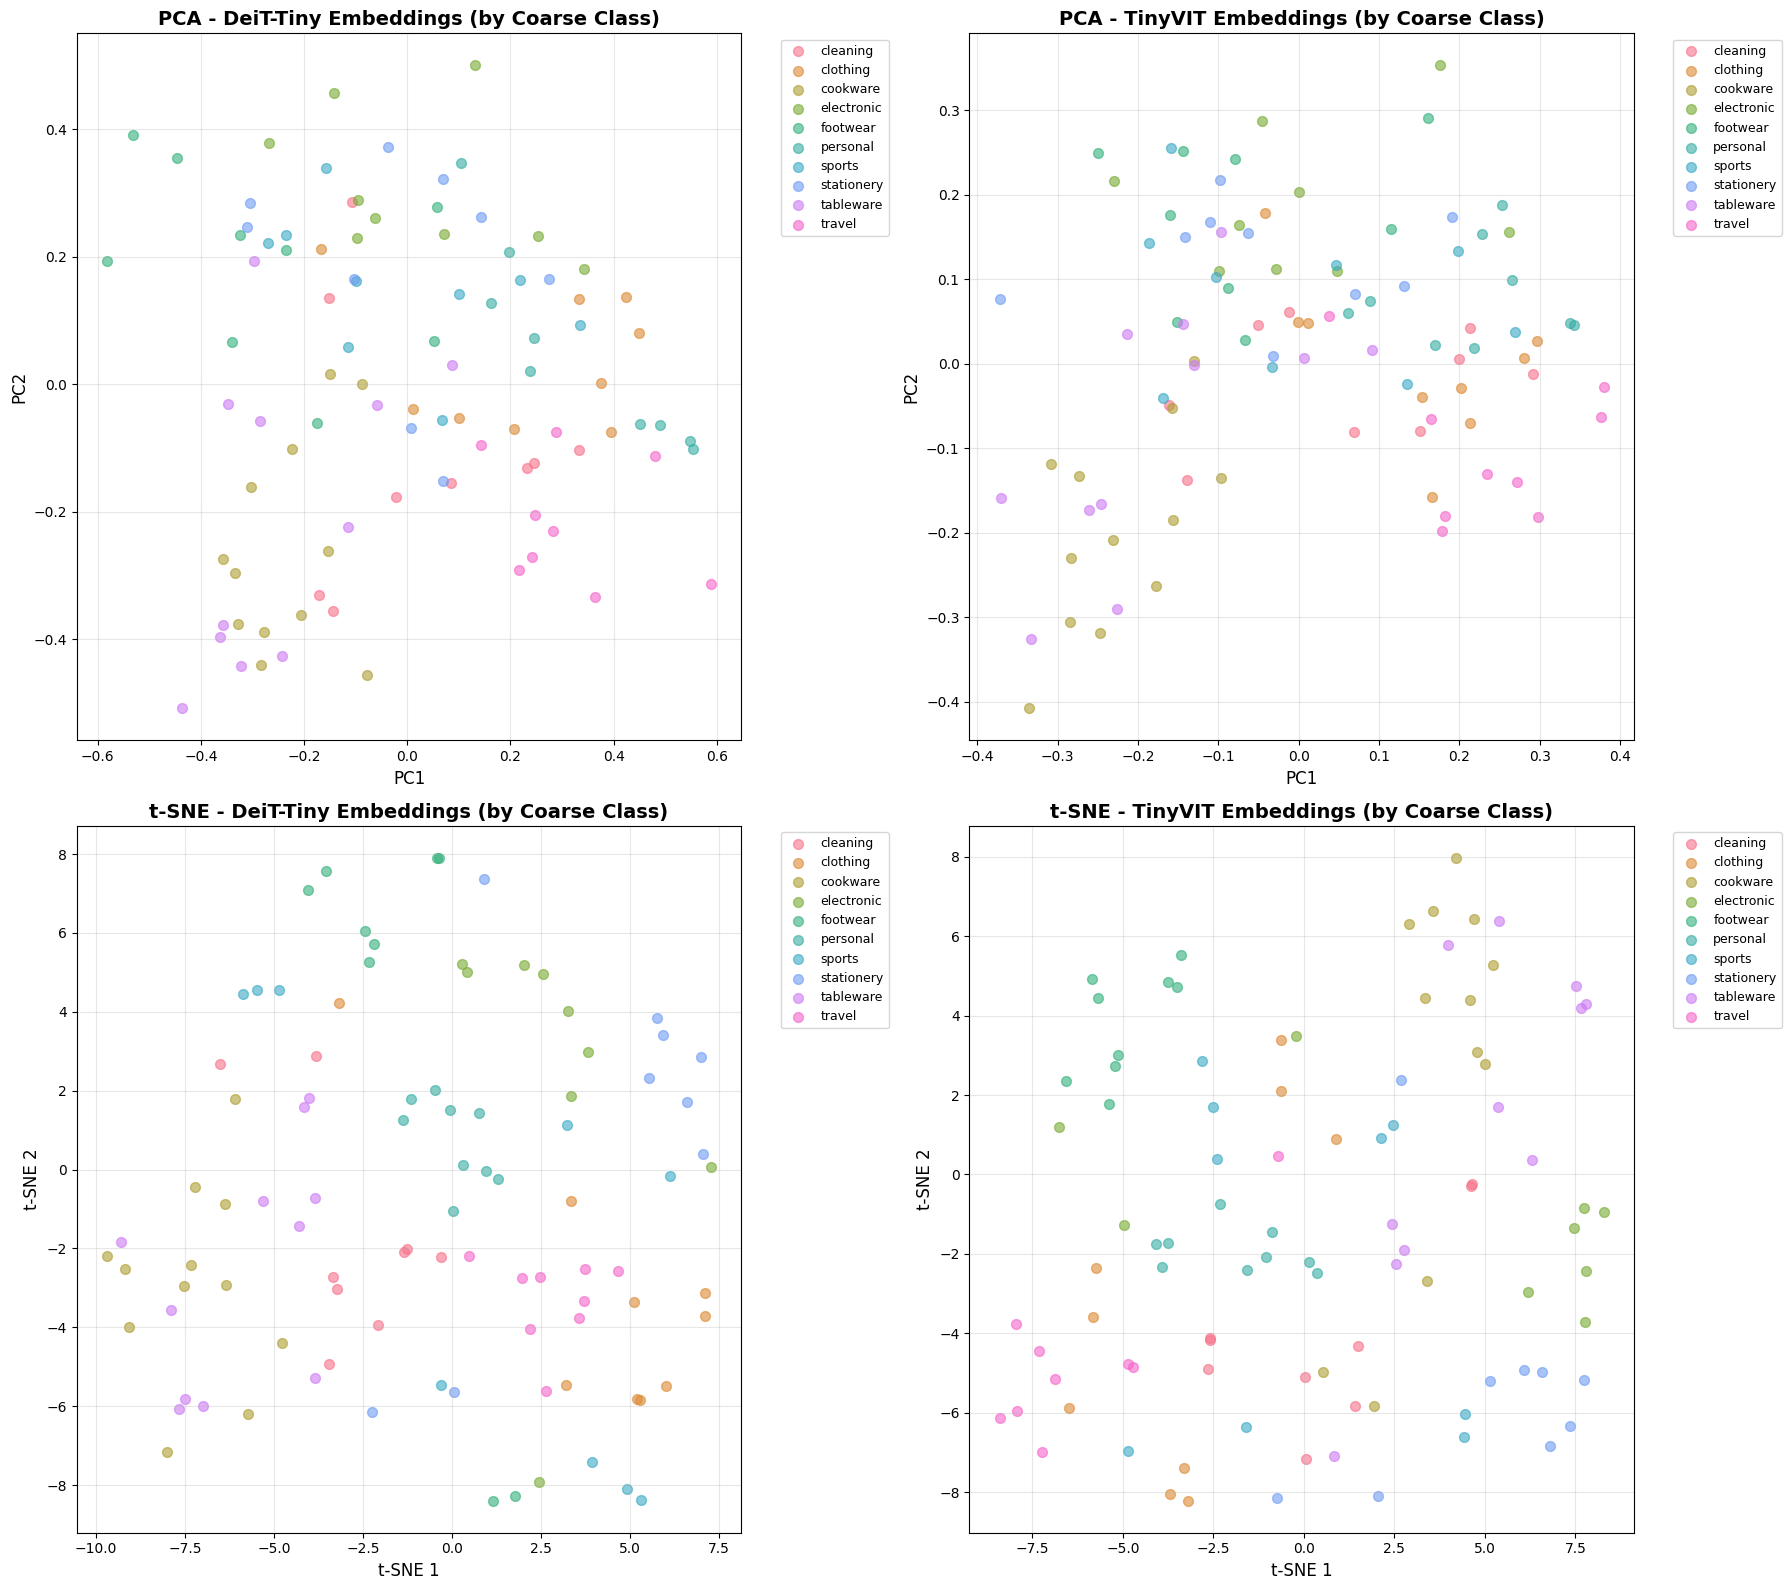

✅ Embedding visualizations complete!
   PCA explained variance (DeiT): 13.82%
   Samples visualized: 95


In [26]:
# 📊 VISUALIZATION 1: T-SNE & PCA - Embedding Space Analysis

print("🎨 Generating embedding visualizations (T-SNE & PCA)...")

from sklearn.manifold import TSNE
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns

# Extract embeddings and labels from test set
def extract_embeddings(model, loader):
    """Extract image embeddings and labels from a model."""
    model.eval()
    all_embeddings = []
    all_coarse_labels = []
    all_fine_labels = []
    
    with torch.no_grad():
        for images, facet_ids, captions, _ in loader:
            images = images.to(device, non_blocking=True)
            
            with torch.cuda.amp.autocast(enabled=(device.type=='cuda')):
                _, _, img_emb = model(images)
            
            all_embeddings.append(img_emb.cpu().numpy())
            all_coarse_labels.extend([d['coarse_class'] for d in facet_ids])
            all_fine_labels.extend([d['fine_class'] for d in facet_ids])
    
    embeddings = np.vstack(all_embeddings)
    coarse_labels = np.array(all_coarse_labels)
    fine_labels = np.array(all_fine_labels)
    
    return embeddings, coarse_labels, fine_labels

# Extract embeddings for both models
print("Extracting embeddings from DeiT model...")
emb_deit, coarse_labels, fine_labels = extract_embeddings(model_unified, test_loader_unified)

print("Extracting embeddings from TinyVIT model...")
emb_tinyvit, _, _ = extract_embeddings(model_unified_tinyvit, test_loader_unified)

# Apply dimensionality reduction
print("Applying PCA...")
pca = PCA(n_components=2, random_state=42)
emb_pca_deit = pca.fit_transform(emb_deit)
emb_pca_tinyvit = pca.transform(emb_tinyvit)

print("Applying T-SNE (this may take a moment)...")
tsne = TSNE(n_components=2, random_state=42, perplexity=30, max_iter=1000)
emb_tsne_deit = tsne.fit_transform(emb_deit)

tsne_tiny = TSNE(n_components=2, random_state=42, perplexity=30, max_iter=1000)
emb_tsne_tinyvit = tsne_tiny.fit_transform(emb_tinyvit)

# Create visualization
fig, axes = plt.subplots(2, 2, figsize=(18, 16))

# Get coarse class names
coarse_names = [id_to_facet_value_unified['coarse_class'][i] for i in coarse_labels]

# Color palette
n_classes = len(np.unique(coarse_labels))
colors = sns.color_palette("husl", n_classes)

# PCA - DeiT
ax = axes[0, 0]
for i, class_id in enumerate(sorted(np.unique(coarse_labels))):
    mask = coarse_labels == class_id
    ax.scatter(emb_pca_deit[mask, 0], emb_pca_deit[mask, 1], 
               c=[colors[i]], label=id_to_facet_value_unified['coarse_class'][class_id],
               alpha=0.6, s=50)
ax.set_xlabel('PC1', fontsize=12)
ax.set_ylabel('PC2', fontsize=12)
ax.set_title('PCA - DeiT-Tiny Embeddings (by Coarse Class)', fontsize=14, fontweight='bold')
ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=9)
ax.grid(True, alpha=0.3)

# PCA - TinyVIT
ax = axes[0, 1]
for i, class_id in enumerate(sorted(np.unique(coarse_labels))):
    mask = coarse_labels == class_id
    ax.scatter(emb_pca_tinyvit[mask, 0], emb_pca_tinyvit[mask, 1], 
               c=[colors[i]], label=id_to_facet_value_unified['coarse_class'][class_id],
               alpha=0.6, s=50)
ax.set_xlabel('PC1', fontsize=12)
ax.set_ylabel('PC2', fontsize=12)
ax.set_title('PCA - TinyVIT Embeddings (by Coarse Class)', fontsize=14, fontweight='bold')
ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=9)
ax.grid(True, alpha=0.3)

# T-SNE - DeiT
ax = axes[1, 0]
for i, class_id in enumerate(sorted(np.unique(coarse_labels))):
    mask = coarse_labels == class_id
    ax.scatter(emb_tsne_deit[mask, 0], emb_tsne_deit[mask, 1], 
               c=[colors[i]], label=id_to_facet_value_unified['coarse_class'][class_id],
               alpha=0.6, s=50)
ax.set_xlabel('t-SNE 1', fontsize=12)
ax.set_ylabel('t-SNE 2', fontsize=12)
ax.set_title('t-SNE - DeiT-Tiny Embeddings (by Coarse Class)', fontsize=14, fontweight='bold')
ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=9)
ax.grid(True, alpha=0.3)

# T-SNE - TinyVIT
ax = axes[1, 1]
for i, class_id in enumerate(sorted(np.unique(coarse_labels))):
    mask = coarse_labels == class_id
    ax.scatter(emb_tsne_tinyvit[mask, 0], emb_tsne_tinyvit[mask, 1], 
               c=[colors[i]], label=id_to_facet_value_unified['coarse_class'][class_id],
               alpha=0.6, s=50)
ax.set_xlabel('t-SNE 1', fontsize=12)
ax.set_ylabel('t-SNE 2', fontsize=12)
ax.set_title('t-SNE - TinyVIT Embeddings (by Coarse Class)', fontsize=14, fontweight='bold')
ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=9)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"✅ Embedding visualizations complete!")
print(f"   PCA explained variance (DeiT): {pca.explained_variance_ratio_.sum():.2%}")
print(f"   Samples visualized: {len(emb_deit)}")


🎨 Generating confusion matrices...


/tmp/ipykernel_20358/26350268.py:20: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=(device.type=='cuda')):


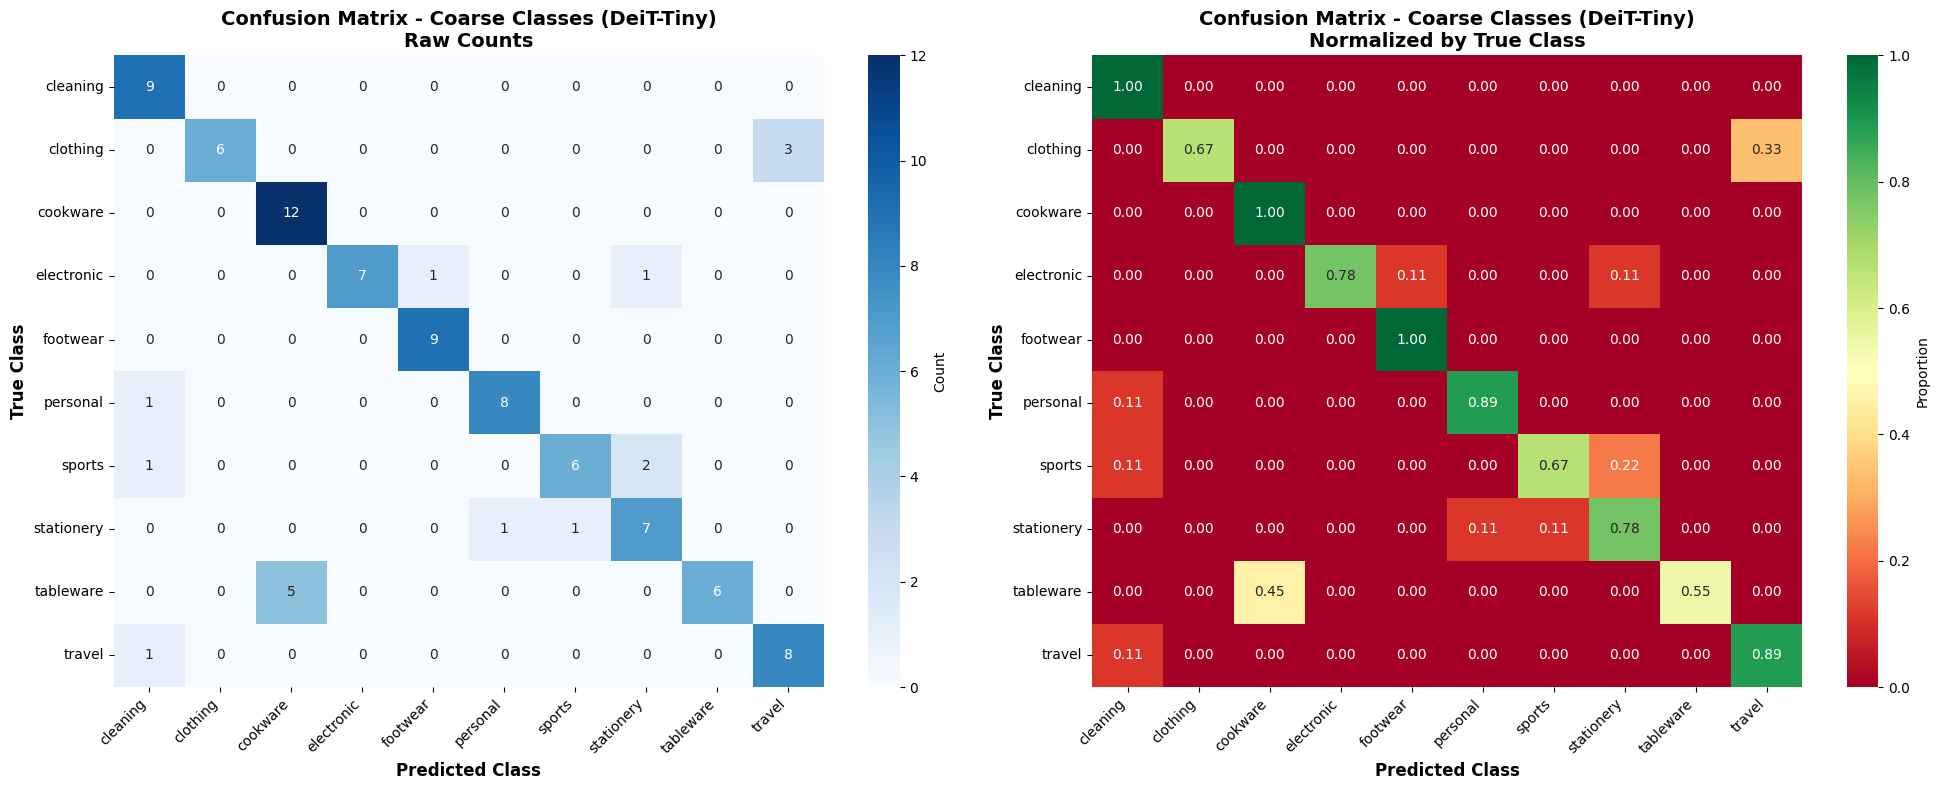


📊 Attribute Confusion Matrices:


/tmp/ipykernel_20358/26350268.py:20: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=(device.type=='cuda')):
/tmp/ipykernel_20358/26350268.py:20: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=(device.type=='cuda')):
/tmp/ipykernel_20358/26350268.py:20: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=(device.type=='cuda')):
/tmp/ipykernel_20358/26350268.py:20: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=(device.type=='cuda')):


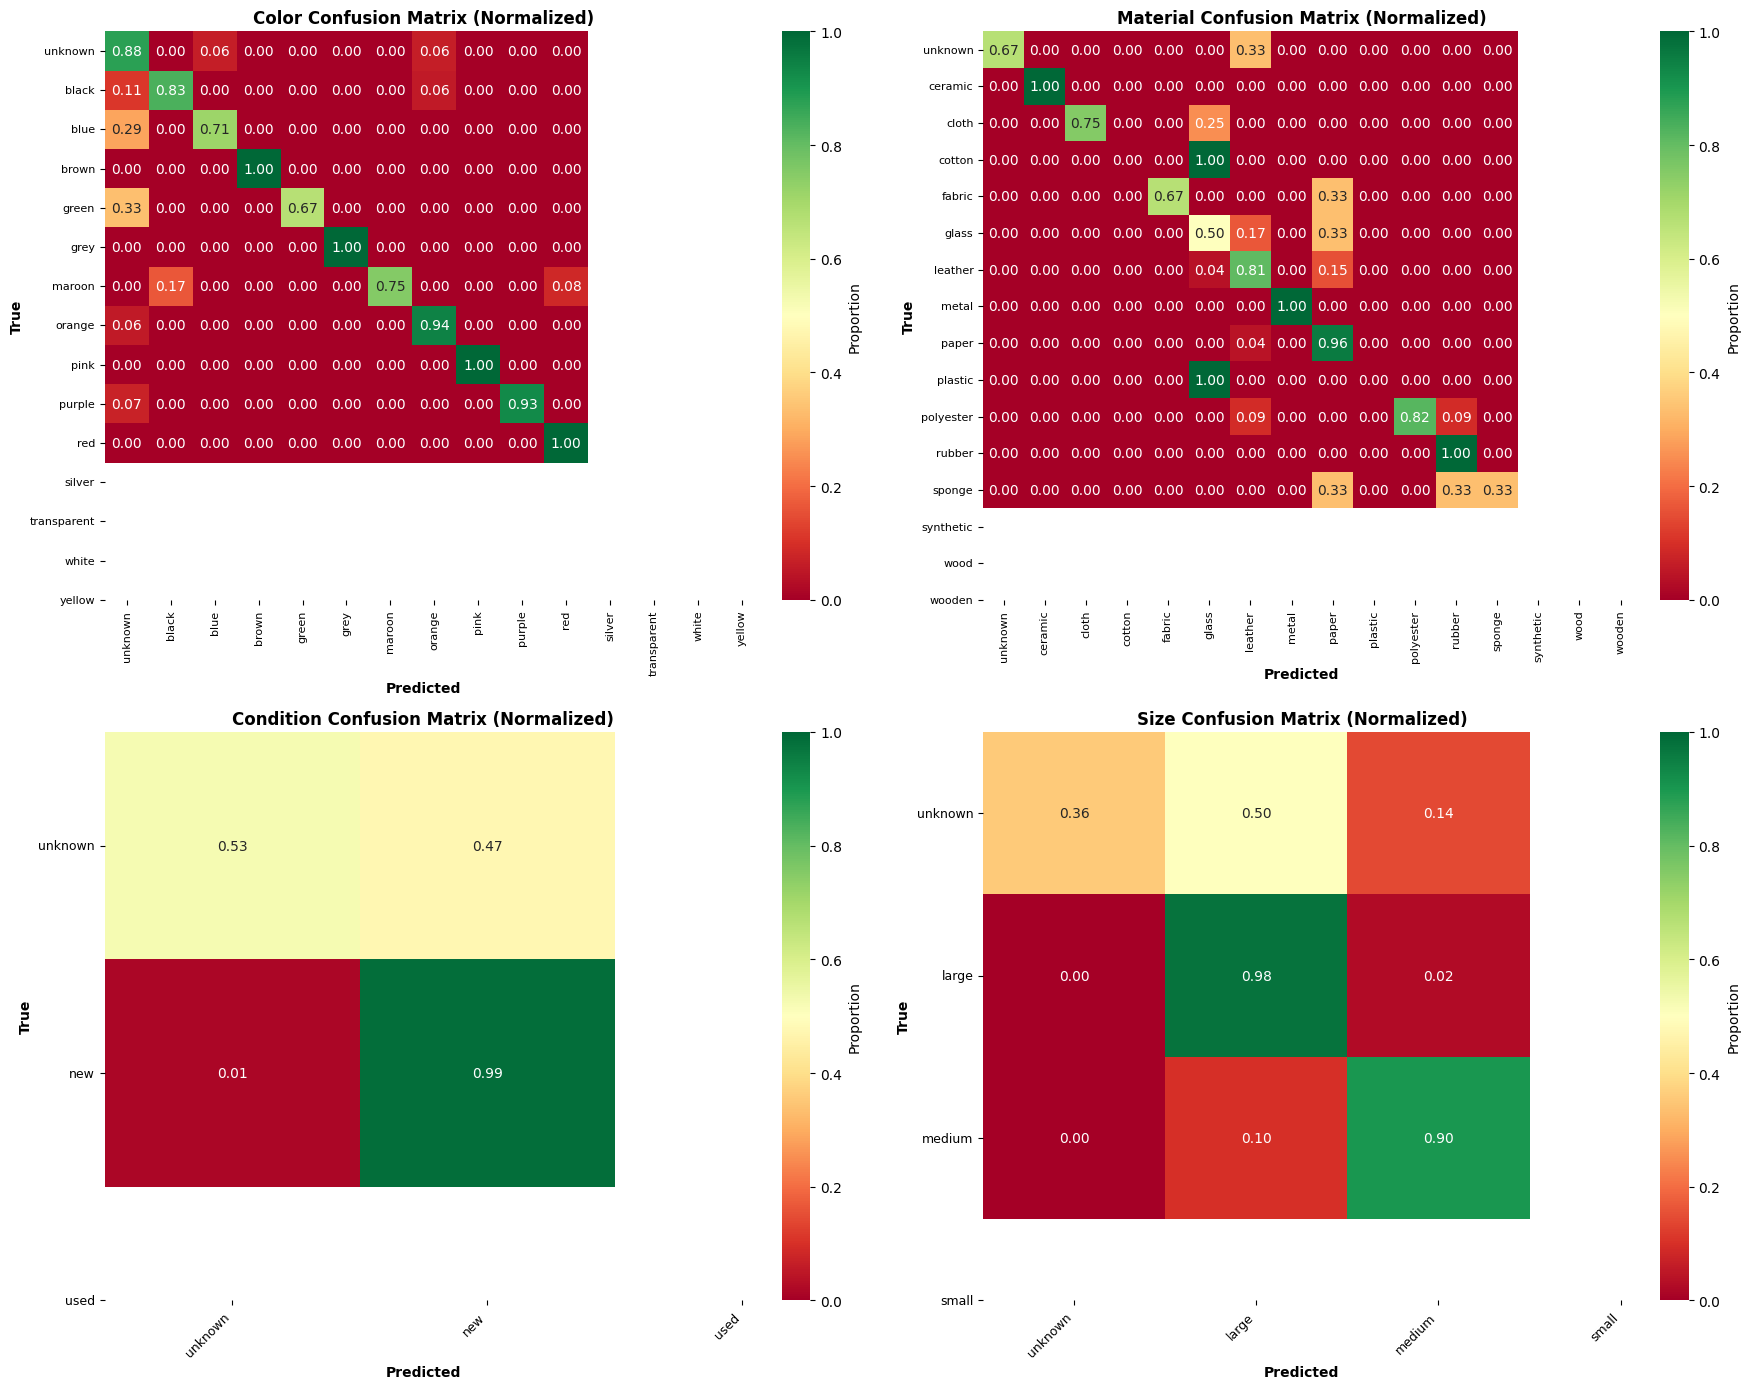

✅ Confusion matrices generated!


In [22]:
# 📊 VISUALIZATION 2: Confusion Matrices

print("🎨 Generating confusion matrices...")

from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

def get_predictions(model, loader, facet_name):
    """Get predictions and ground truth for a specific facet."""
    model.eval()
    all_preds = []
    all_targets = []
    
    with torch.no_grad():
        for images, facet_ids, captions, _ in loader:
            images = images.to(device, non_blocking=True)
            facet_batch = {f: torch.as_tensor([d[f] for d in facet_ids], device=device) for f in FACETS_UNIFIED}
            
            with torch.cuda.amp.autocast(enabled=(device.type=='cuda')):
                _, logits_attrs, _ = model(images)
            
            preds = logits_attrs[facet_name].argmax(dim=1).cpu().numpy()
            targets = facet_batch[facet_name].cpu().numpy()
            
            all_preds.extend(preds)
            all_targets.extend(targets)
    
    return np.array(all_preds), np.array(all_targets)

# Get predictions for coarse classes
preds_coarse, targets_coarse = get_predictions(model_unified, test_loader_unified, 'coarse_class')
cm_coarse = confusion_matrix(targets_coarse, preds_coarse)

# Normalize confusion matrix
cm_coarse_norm = cm_coarse.astype('float') / cm_coarse.sum(axis=1)[:, np.newaxis]

# Create figure
fig, axes = plt.subplots(1, 2, figsize=(20, 8))

# Confusion Matrix - Raw Counts
ax = axes[0]
class_names = [id_to_facet_value_unified['coarse_class'][i] for i in range(len(coarse_classes))]
sns.heatmap(cm_coarse, annot=True, fmt='d', cmap='Blues', 
            xticklabels=class_names, yticklabels=class_names, ax=ax, cbar_kws={'label': 'Count'})
ax.set_xlabel('Predicted Class', fontsize=12, fontweight='bold')
ax.set_ylabel('True Class', fontsize=12, fontweight='bold')
ax.set_title('Confusion Matrix - Coarse Classes (DeiT-Tiny)\nRaw Counts', fontsize=14, fontweight='bold')
plt.setp(ax.get_xticklabels(), rotation=45, ha='right')
plt.setp(ax.get_yticklabels(), rotation=0)

# Confusion Matrix - Normalized
ax = axes[1]
sns.heatmap(cm_coarse_norm, annot=True, fmt='.2f', cmap='RdYlGn', 
            xticklabels=class_names, yticklabels=class_names, ax=ax, 
            vmin=0, vmax=1, cbar_kws={'label': 'Proportion'})
ax.set_xlabel('Predicted Class', fontsize=12, fontweight='bold')
ax.set_ylabel('True Class', fontsize=12, fontweight='bold')
ax.set_title('Confusion Matrix - Coarse Classes (DeiT-Tiny)\nNormalized by True Class', fontsize=14, fontweight='bold')
plt.setp(ax.get_xticklabels(), rotation=45, ha='right')
plt.setp(ax.get_yticklabels(), rotation=0)

plt.tight_layout()
plt.show()

# Get confusion for attributes
print("\n📊 Attribute Confusion Matrices:")

fig, axes = plt.subplots(2, 2, figsize=(18, 14))
attributes = ['color', 'material', 'condition', 'size']

for idx, attr in enumerate(attributes):
    preds_attr, targets_attr = get_predictions(model_unified, test_loader_unified, attr)
    cm_attr = confusion_matrix(targets_attr, preds_attr)
    cm_attr_norm = cm_attr.astype('float') / cm_attr.sum(axis=1)[:, np.newaxis]
    
    ax = axes[idx // 2, idx % 2]
    
    attr_names = [id_to_facet_value_unified[attr][i] for i in range(len(facet_to_values_unified[attr]))]
    
    # Show normalized for attributes (easier to read)
    sns.heatmap(cm_attr_norm, annot=True, fmt='.2f', cmap='RdYlGn', 
                xticklabels=attr_names, yticklabels=attr_names, ax=ax,
                vmin=0, vmax=1, cbar_kws={'label': 'Proportion'})
    ax.set_xlabel('Predicted', fontsize=10, fontweight='bold')
    ax.set_ylabel('True', fontsize=10, fontweight='bold')
    ax.set_title(f'{attr.capitalize()} Confusion Matrix (Normalized)', fontsize=12, fontweight='bold')
    
    if len(attr_names) > 8:
        plt.setp(ax.get_xticklabels(), rotation=90, fontsize=8)
        plt.setp(ax.get_yticklabels(), rotation=0, fontsize=8)
    else:
        plt.setp(ax.get_xticklabels(), rotation=45, ha='right', fontsize=9)
        plt.setp(ax.get_yticklabels(), rotation=0, fontsize=9)

plt.tight_layout()
plt.show()

print("✅ Confusion matrices generated!")


🎨 Generating performance comparison visualizations...


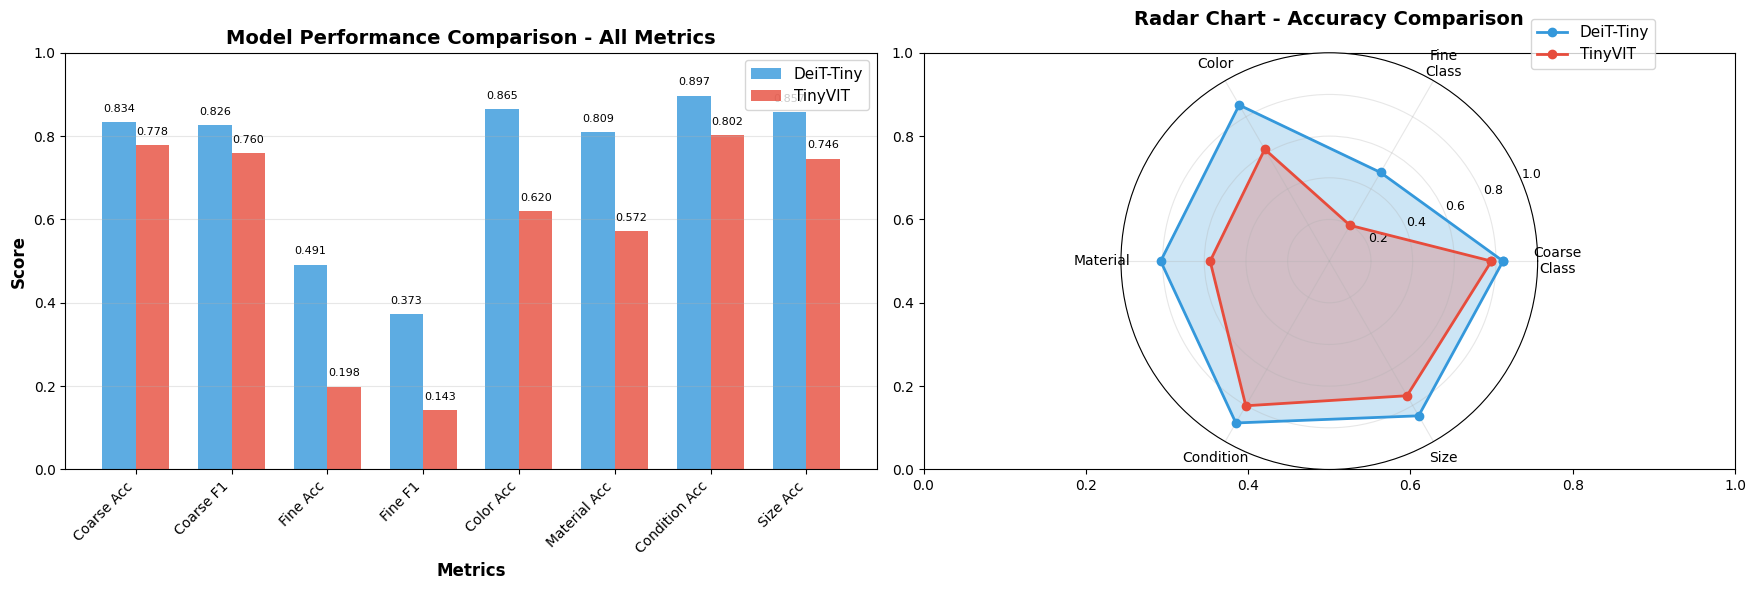

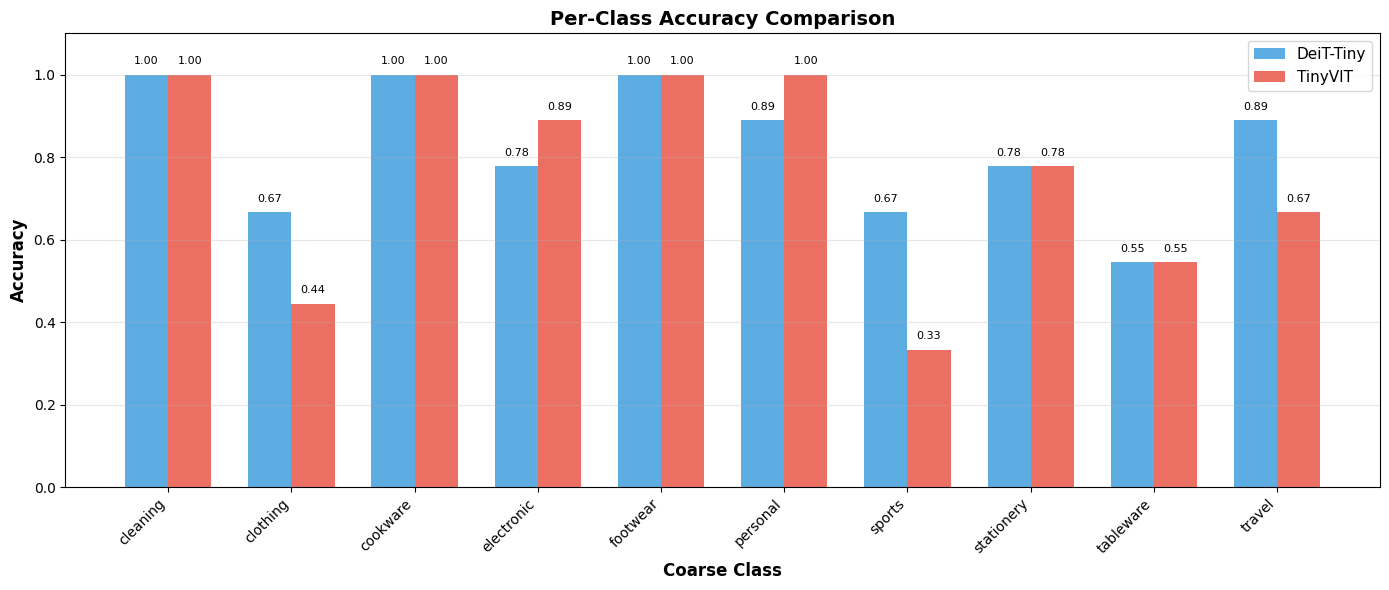

✅ Performance comparison visualizations generated!


In [23]:
# 📊 VISUALIZATION 3: Performance Comparison Charts

print("🎨 Generating performance comparison visualizations...")

import matplotlib.pyplot as plt
import seaborn as sns

# Prepare data for visualization
metrics_comparison = {
    'Coarse Acc': [test_metrics_unified['coarse_class_acc'], test_metrics_tinyvit['coarse_class_acc']],
    'Coarse F1': [test_metrics_unified['coarse_class_f1'], test_metrics_tinyvit['coarse_class_f1']],
    'Fine Acc': [test_metrics_unified['fine_class_acc'], test_metrics_tinyvit['fine_class_acc']],
    'Fine F1': [test_metrics_unified['fine_class_f1'], test_metrics_tinyvit['fine_class_f1']],
    'Color Acc': [test_metrics_unified['color_acc'], test_metrics_tinyvit['color_acc']],
    'Material Acc': [test_metrics_unified['material_acc'], test_metrics_tinyvit['material_acc']],
    'Condition Acc': [test_metrics_unified['condition_acc'], test_metrics_tinyvit['condition_acc']],
    'Size Acc': [test_metrics_unified['size_acc'], test_metrics_tinyvit['size_acc']],
}

model_names = ['DeiT-Tiny', 'TinyVIT']

# 1. Bar Chart Comparison
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Overall metrics
ax = axes[0]
x = np.arange(len(metrics_comparison))
width = 0.35
bars1 = ax.bar(x - width/2, [v[0] for v in metrics_comparison.values()], width, label='DeiT-Tiny', color='#3498db', alpha=0.8)
bars2 = ax.bar(x + width/2, [v[1] for v in metrics_comparison.values()], width, label='TinyVIT', color='#e74c3c', alpha=0.8)

ax.set_xlabel('Metrics', fontsize=12, fontweight='bold')
ax.set_ylabel('Score', fontsize=12, fontweight='bold')
ax.set_title('Model Performance Comparison - All Metrics', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(metrics_comparison.keys(), rotation=45, ha='right')
ax.legend(fontsize=11)
ax.grid(axis='y', alpha=0.3)
ax.set_ylim(0, 1.0)

# Add value labels on bars
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height + 0.02,
                f'{height:.3f}', ha='center', va='bottom', fontsize=8)

# 2. Radar Chart
ax = axes[1]

categories = ['Coarse\nClass', 'Fine\nClass', 'Color', 'Material', 'Condition', 'Size']
values_deit = [
    test_metrics_unified['coarse_class_acc'],
    test_metrics_unified['fine_class_acc'],
    test_metrics_unified['color_acc'],
    test_metrics_unified['material_acc'],
    test_metrics_unified['condition_acc'],
    test_metrics_unified['size_acc']
]
values_tinyvit = [
    test_metrics_tinyvit['coarse_class_acc'],
    test_metrics_tinyvit['fine_class_acc'],
    test_metrics_tinyvit['color_acc'],
    test_metrics_tinyvit['material_acc'],
    test_metrics_tinyvit['condition_acc'],
    test_metrics_tinyvit['size_acc']
]

# Close the plot
values_deit += values_deit[:1]
values_tinyvit += values_tinyvit[:1]

# Create angles for radar chart
angles = np.linspace(0, 2 * np.pi, len(categories), endpoint=False).tolist()
angles += angles[:1]

ax = plt.subplot(122, projection='polar')
ax.plot(angles, values_deit, 'o-', linewidth=2, label='DeiT-Tiny', color='#3498db')
ax.fill(angles, values_deit, alpha=0.25, color='#3498db')
ax.plot(angles, values_tinyvit, 'o-', linewidth=2, label='TinyVIT', color='#e74c3c')
ax.fill(angles, values_tinyvit, alpha=0.25, color='#e74c3c')

ax.set_xticks(angles[:-1])
ax.set_xticklabels(categories, fontsize=10)
ax.set_ylim(0, 1.0)
ax.set_yticks([0.2, 0.4, 0.6, 0.8, 1.0])
ax.set_yticklabels(['0.2', '0.4', '0.6', '0.8', '1.0'], fontsize=9)
ax.set_title('Radar Chart - Accuracy Comparison', fontsize=14, fontweight='bold', pad=20)
ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1), fontsize=11)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# 3. Per-class accuracy comparison
fig, ax = plt.subplots(figsize=(14, 6))

class_names_sorted = sorted(coarse_acc_deit.keys())
class_labels = [id_to_facet_value_unified['coarse_class'][i] for i in class_names_sorted]
deit_accs = [coarse_acc_deit[i] for i in class_names_sorted]
tiny_accs = [coarse_acc_tiny[i] for i in class_names_sorted]

x = np.arange(len(class_labels))
width = 0.35

bars1 = ax.bar(x - width/2, deit_accs, width, label='DeiT-Tiny', color='#3498db', alpha=0.8)
bars2 = ax.bar(x + width/2, tiny_accs, width, label='TinyVIT', color='#e74c3c', alpha=0.8)

ax.set_xlabel('Coarse Class', fontsize=12, fontweight='bold')
ax.set_ylabel('Accuracy', fontsize=12, fontweight='bold')
ax.set_title('Per-Class Accuracy Comparison', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(class_labels, rotation=45, ha='right')
ax.legend(fontsize=11)
ax.grid(axis='y', alpha=0.3)
ax.set_ylim(0, 1.1)

# Add value labels
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        if height > 0:
            ax.text(bar.get_x() + bar.get_width()/2., height + 0.02,
                    f'{height:.2f}', ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.show()

print("✅ Performance comparison visualizations generated!")


🎨 Analyzing prediction confidence distributions...


/tmp/ipykernel_20358/1179085655.py:25: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=(device.type=='cuda')):


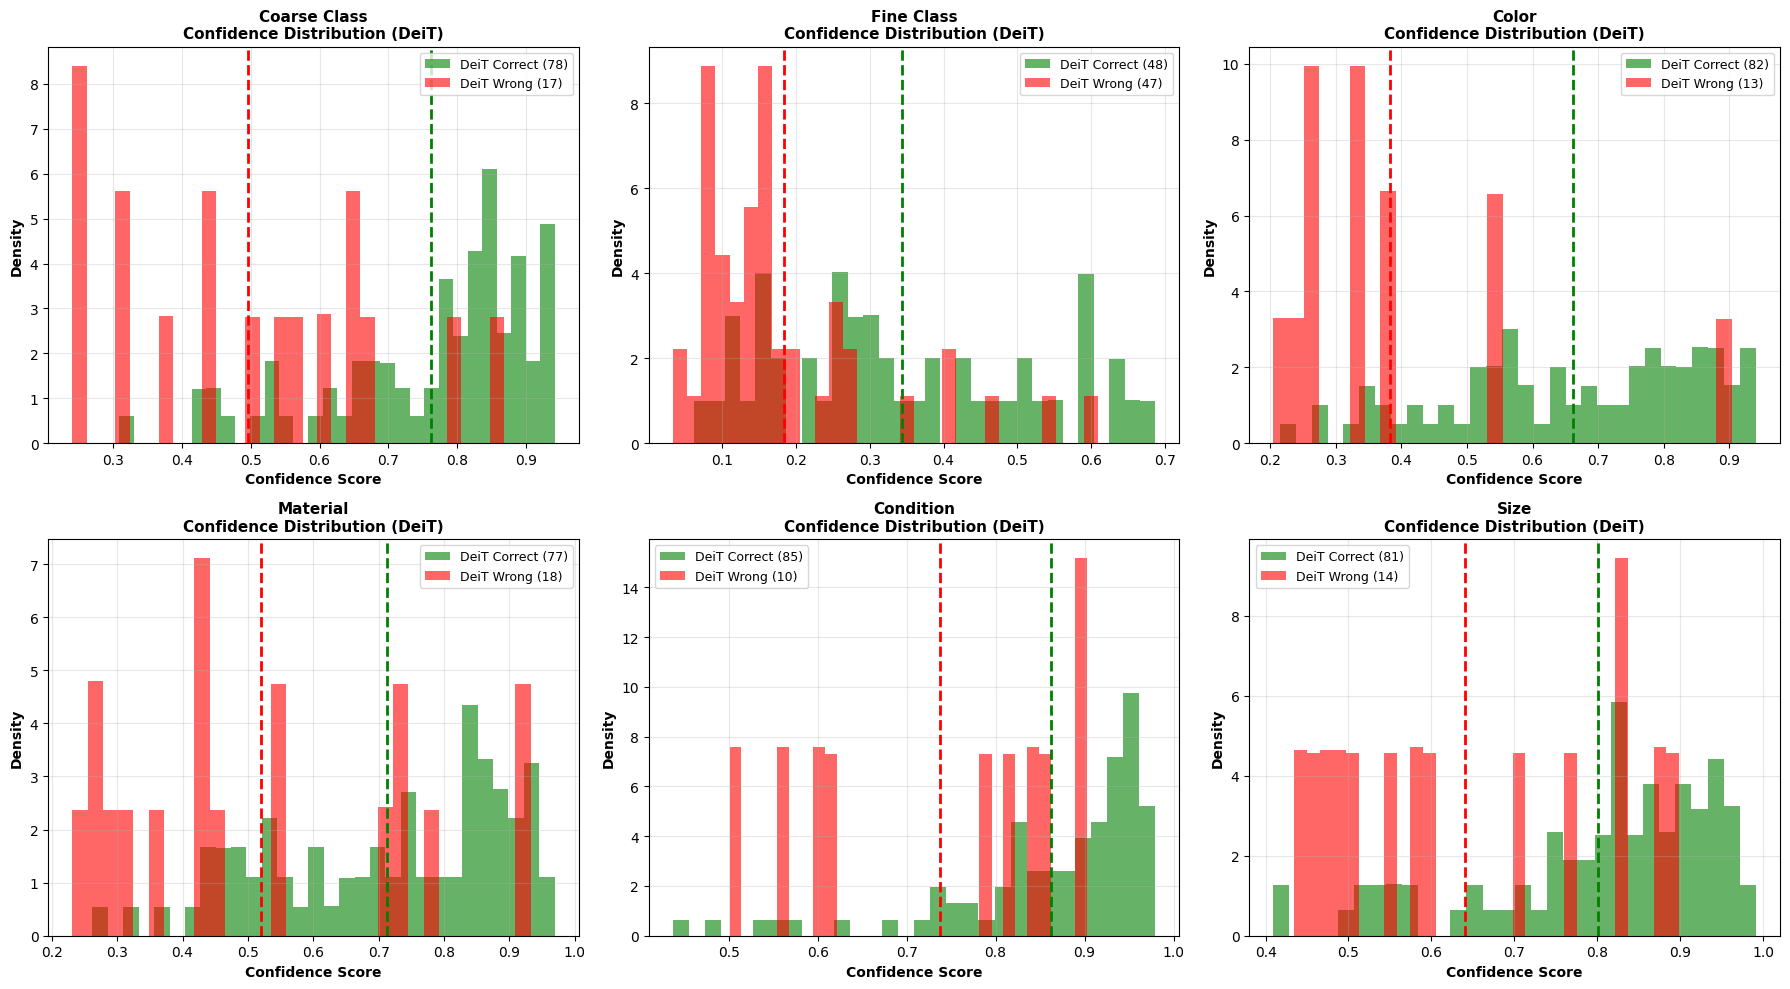

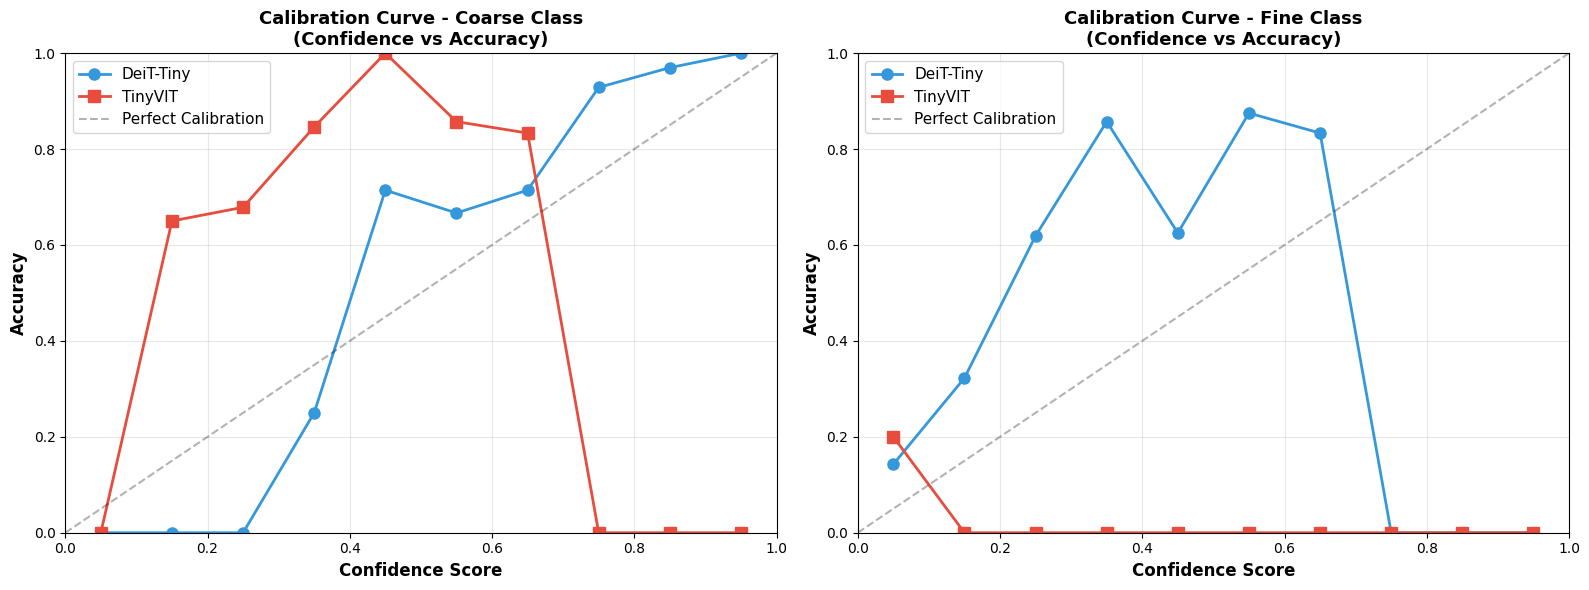

✅ Confidence analysis complete!

DeiT-Tiny Average Confidence:
  coarse_class: 0.714
  fine_class: 0.265
  color: 0.624
  material: 0.677
  condition: 0.850
  size: 0.778

TinyVIT Average Confidence:
  coarse_class: 0.324
  fine_class: 0.026
  color: 0.322
  material: 0.424
  condition: 0.765
  size: 0.624


In [24]:
# 📊 VISUALIZATION 4: Confidence Score Analysis

print("🎨 Analyzing prediction confidence distributions...")

import matplotlib.pyplot as plt
import seaborn as sns

def get_predictions_with_confidence(model, loader):
    """Get predictions with confidence scores."""
    model.eval()
    results = {
        'coarse_class': {'confidences': [], 'correct': []},
        'fine_class': {'confidences': [], 'correct': []},
        'color': {'confidences': [], 'correct': []},
        'material': {'confidences': [], 'correct': []},
        'condition': {'confidences': [], 'correct': []},
        'size': {'confidences': [], 'correct': []}
    }
    
    with torch.no_grad():
        for images, facet_ids, captions, _ in loader:
            images = images.to(device, non_blocking=True)
            facet_batch = {f: torch.as_tensor([d[f] for d in facet_ids], device=device) for f in FACETS_UNIFIED}
            
            with torch.cuda.amp.autocast(enabled=(device.type=='cuda')):
                _, logits_attrs, _ = model(images)
            
            for facet in FACETS_UNIFIED:
                probs = torch.softmax(logits_attrs[facet], dim=1)
                confidences = probs.max(dim=1)[0].cpu().numpy()
                preds = logits_attrs[facet].argmax(dim=1)
                targets = facet_batch[facet]
                correct = (preds == targets).cpu().numpy()
                
                results[facet]['confidences'].extend(confidences)
                results[facet]['correct'].extend(correct)
    
    return results

# Get confidence scores
conf_deit = get_predictions_with_confidence(model_unified, test_loader_unified)
conf_tinyvit = get_predictions_with_confidence(model_unified_tinyvit, test_loader_unified)

# Plot confidence distributions
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

facets = ['coarse_class', 'fine_class', 'color', 'material', 'condition', 'size']
facet_titles = ['Coarse Class', 'Fine Class', 'Color', 'Material', 'Condition', 'Size']

for idx, (facet, title) in enumerate(zip(facets, facet_titles)):
    ax = axes[idx // 3, idx % 3]
    
    # DeiT confidences
    conf_correct_deit = [c for c, correct in zip(conf_deit[facet]['confidences'], conf_deit[facet]['correct']) if correct]
    conf_wrong_deit = [c for c, correct in zip(conf_deit[facet]['confidences'], conf_deit[facet]['correct']) if not correct]
    
    # Plot distributions
    ax.hist(conf_correct_deit, bins=30, alpha=0.6, label=f'DeiT Correct ({len(conf_correct_deit)})', 
            color='green', density=True)
    ax.hist(conf_wrong_deit, bins=30, alpha=0.6, label=f'DeiT Wrong ({len(conf_wrong_deit)})', 
            color='red', density=True)
    
    ax.set_xlabel('Confidence Score', fontsize=10, fontweight='bold')
    ax.set_ylabel('Density', fontsize=10, fontweight='bold')
    ax.set_title(f'{title}\nConfidence Distribution (DeiT)', fontsize=11, fontweight='bold')
    ax.legend(fontsize=9)
    ax.grid(alpha=0.3)
    
    # Add mean lines
    if conf_correct_deit:
        ax.axvline(np.mean(conf_correct_deit), color='green', linestyle='--', linewidth=2, 
                   label=f'Mean Correct: {np.mean(conf_correct_deit):.3f}')
    if conf_wrong_deit:
        ax.axvline(np.mean(conf_wrong_deit), color='red', linestyle='--', linewidth=2,
                   label=f'Mean Wrong: {np.mean(conf_wrong_deit):.3f}')

plt.tight_layout()
plt.show()

# Confidence vs Accuracy scatter
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Coarse class
ax = axes[0]
conf_bins = np.linspace(0, 1, 11)
bin_centers = (conf_bins[:-1] + conf_bins[1:]) / 2

acc_by_conf_deit = []
for i in range(len(conf_bins) - 1):
    mask = (np.array(conf_deit['coarse_class']['confidences']) >= conf_bins[i]) & \
           (np.array(conf_deit['coarse_class']['confidences']) < conf_bins[i+1])
    if mask.sum() > 0:
        acc = np.array(conf_deit['coarse_class']['correct'])[mask].mean()
        acc_by_conf_deit.append(acc)
    else:
        acc_by_conf_deit.append(0)

acc_by_conf_tiny = []
for i in range(len(conf_bins) - 1):
    mask = (np.array(conf_tinyvit['coarse_class']['confidences']) >= conf_bins[i]) & \
           (np.array(conf_tinyvit['coarse_class']['confidences']) < conf_bins[i+1])
    if mask.sum() > 0:
        acc = np.array(conf_tinyvit['coarse_class']['correct'])[mask].mean()
        acc_by_conf_tiny.append(acc)
    else:
        acc_by_conf_tiny.append(0)

ax.plot(bin_centers, acc_by_conf_deit, 'o-', linewidth=2, markersize=8, label='DeiT-Tiny', color='#3498db')
ax.plot(bin_centers, acc_by_conf_tiny, 's-', linewidth=2, markersize=8, label='TinyVIT', color='#e74c3c')
ax.plot([0, 1], [0, 1], 'k--', alpha=0.3, label='Perfect Calibration')

ax.set_xlabel('Confidence Score', fontsize=12, fontweight='bold')
ax.set_ylabel('Accuracy', fontsize=12, fontweight='bold')
ax.set_title('Calibration Curve - Coarse Class\n(Confidence vs Accuracy)', fontsize=13, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(alpha=0.3)
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)

# Fine class
ax = axes[1]
acc_by_conf_deit_fine = []
for i in range(len(conf_bins) - 1):
    mask = (np.array(conf_deit['fine_class']['confidences']) >= conf_bins[i]) & \
           (np.array(conf_deit['fine_class']['confidences']) < conf_bins[i+1])
    if mask.sum() > 0:
        acc = np.array(conf_deit['fine_class']['correct'])[mask].mean()
        acc_by_conf_deit_fine.append(acc)
    else:
        acc_by_conf_deit_fine.append(0)

acc_by_conf_tiny_fine = []
for i in range(len(conf_bins) - 1):
    mask = (np.array(conf_tinyvit['fine_class']['confidences']) >= conf_bins[i]) & \
           (np.array(conf_tinyvit['fine_class']['confidences']) < conf_bins[i+1])
    if mask.sum() > 0:
        acc = np.array(conf_tinyvit['fine_class']['correct'])[mask].mean()
        acc_by_conf_tiny_fine.append(acc)
    else:
        acc_by_conf_tiny_fine.append(0)

ax.plot(bin_centers, acc_by_conf_deit_fine, 'o-', linewidth=2, markersize=8, label='DeiT-Tiny', color='#3498db')
ax.plot(bin_centers, acc_by_conf_tiny_fine, 's-', linewidth=2, markersize=8, label='TinyVIT', color='#e74c3c')
ax.plot([0, 1], [0, 1], 'k--', alpha=0.3, label='Perfect Calibration')

ax.set_xlabel('Confidence Score', fontsize=12, fontweight='bold')
ax.set_ylabel('Accuracy', fontsize=12, fontweight='bold')
ax.set_title('Calibration Curve - Fine Class\n(Confidence vs Accuracy)', fontsize=13, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(alpha=0.3)
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)

plt.tight_layout()
plt.show()

print("✅ Confidence analysis complete!")
print(f"\nDeiT-Tiny Average Confidence:")
for facet in facets:
    avg_conf = np.mean(conf_deit[facet]['confidences'])
    print(f"  {facet}: {avg_conf:.3f}")
    
print(f"\nTinyVIT Average Confidence:")
for facet in facets:
    avg_conf = np.mean(conf_tinyvit[facet]['confidences'])
    print(f"  {facet}: {avg_conf:.3f}")


🎨 Generating sample prediction visualizations...

🖼️  DeiT-Tiny Predictions:


/tmp/ipykernel_20358/3603981539.py:27: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=(device.type=='cuda')):


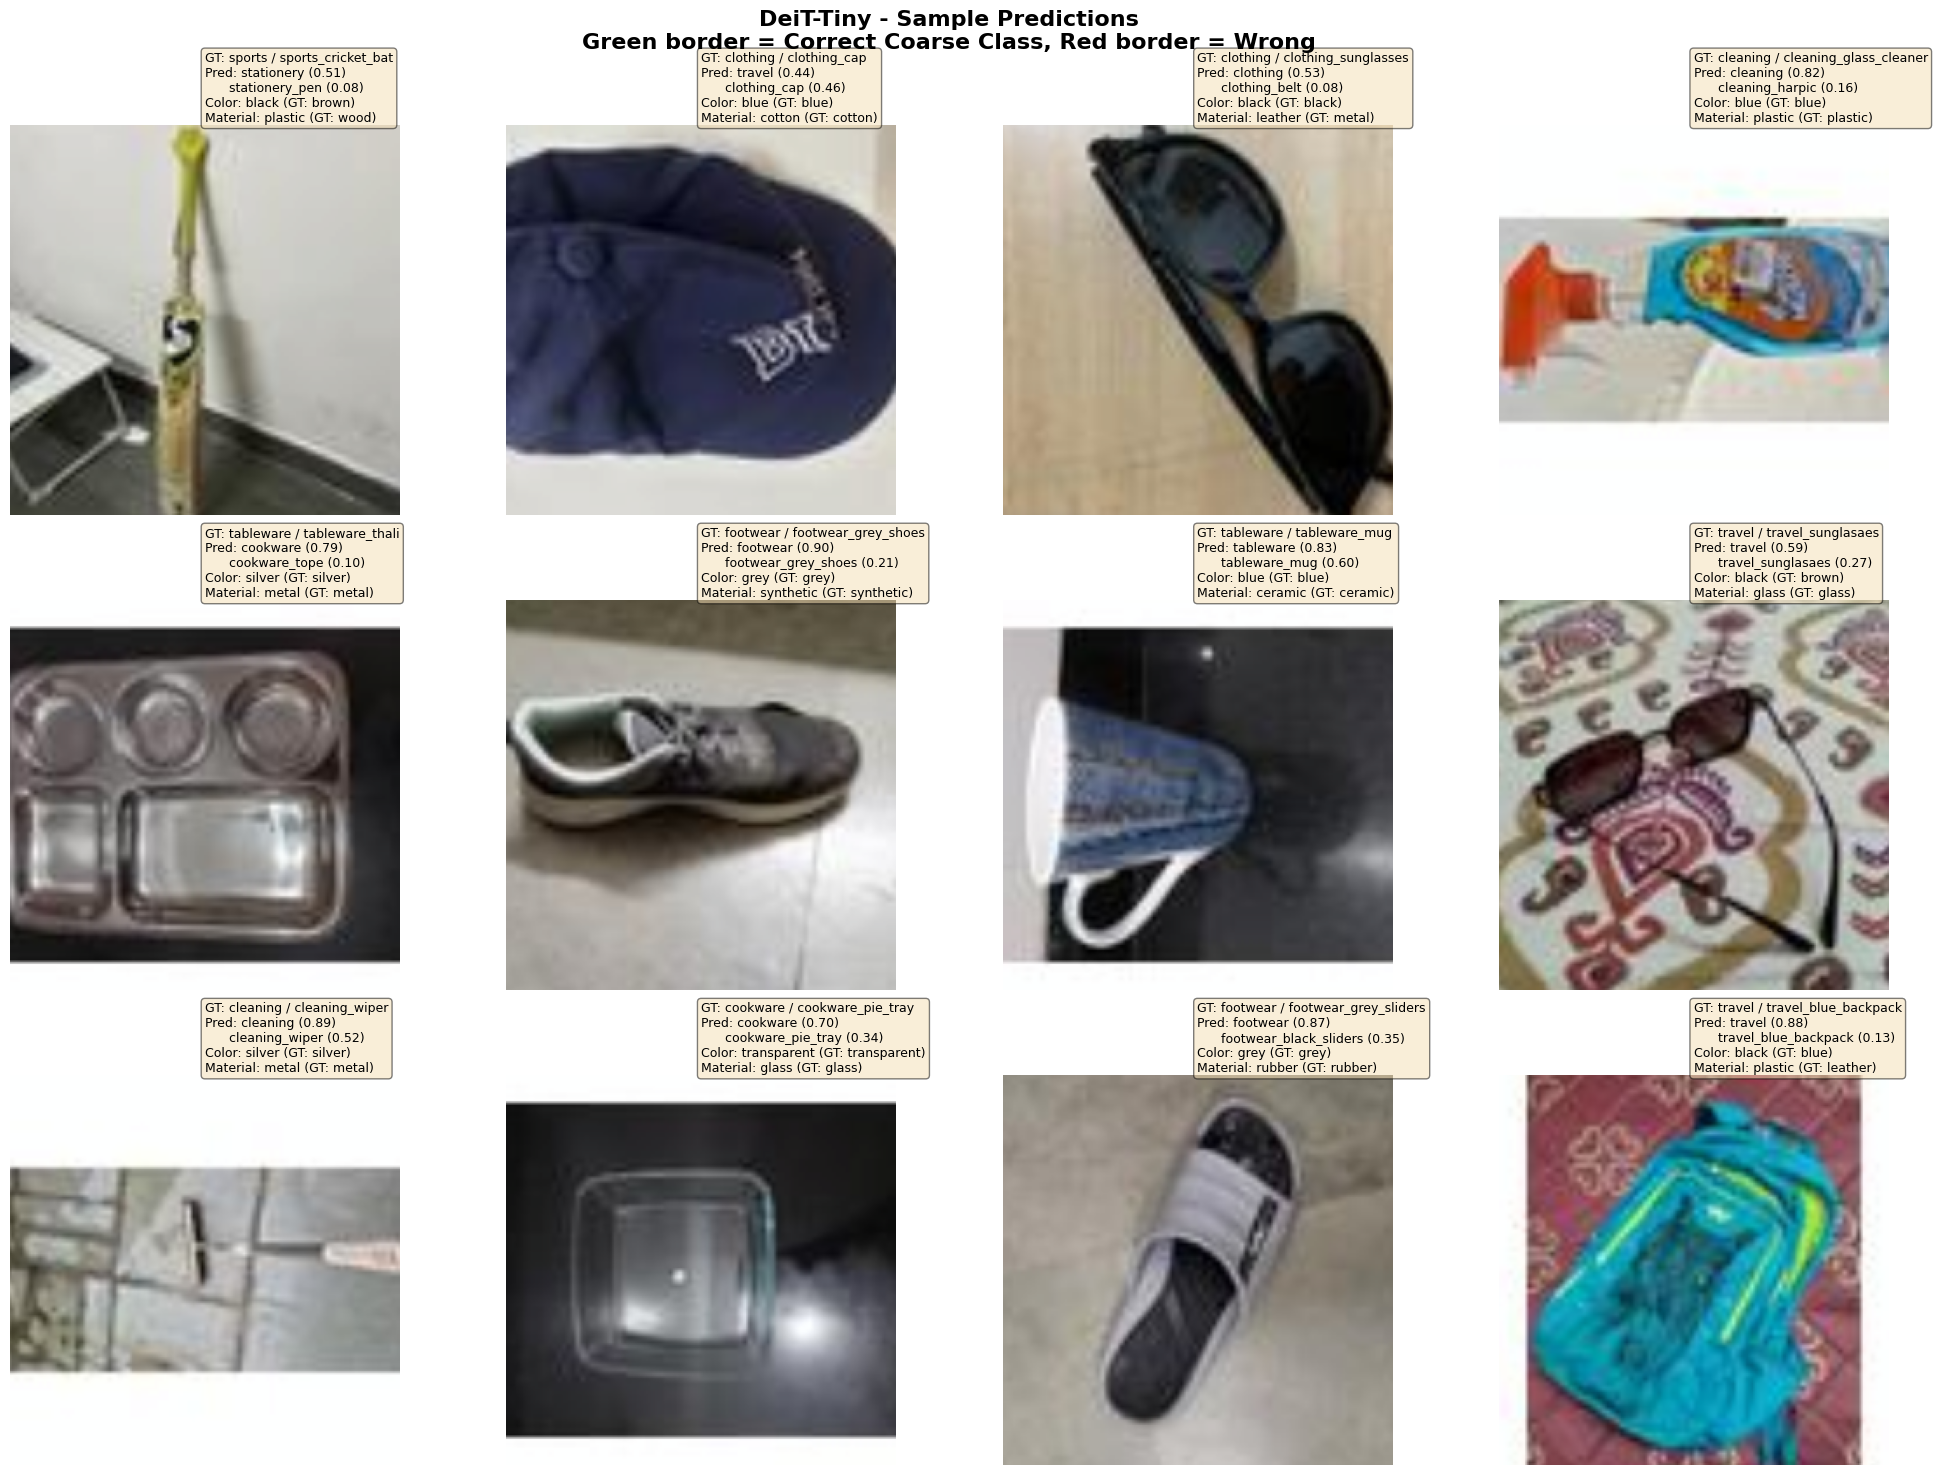


🖼️  TinyVIT Predictions:


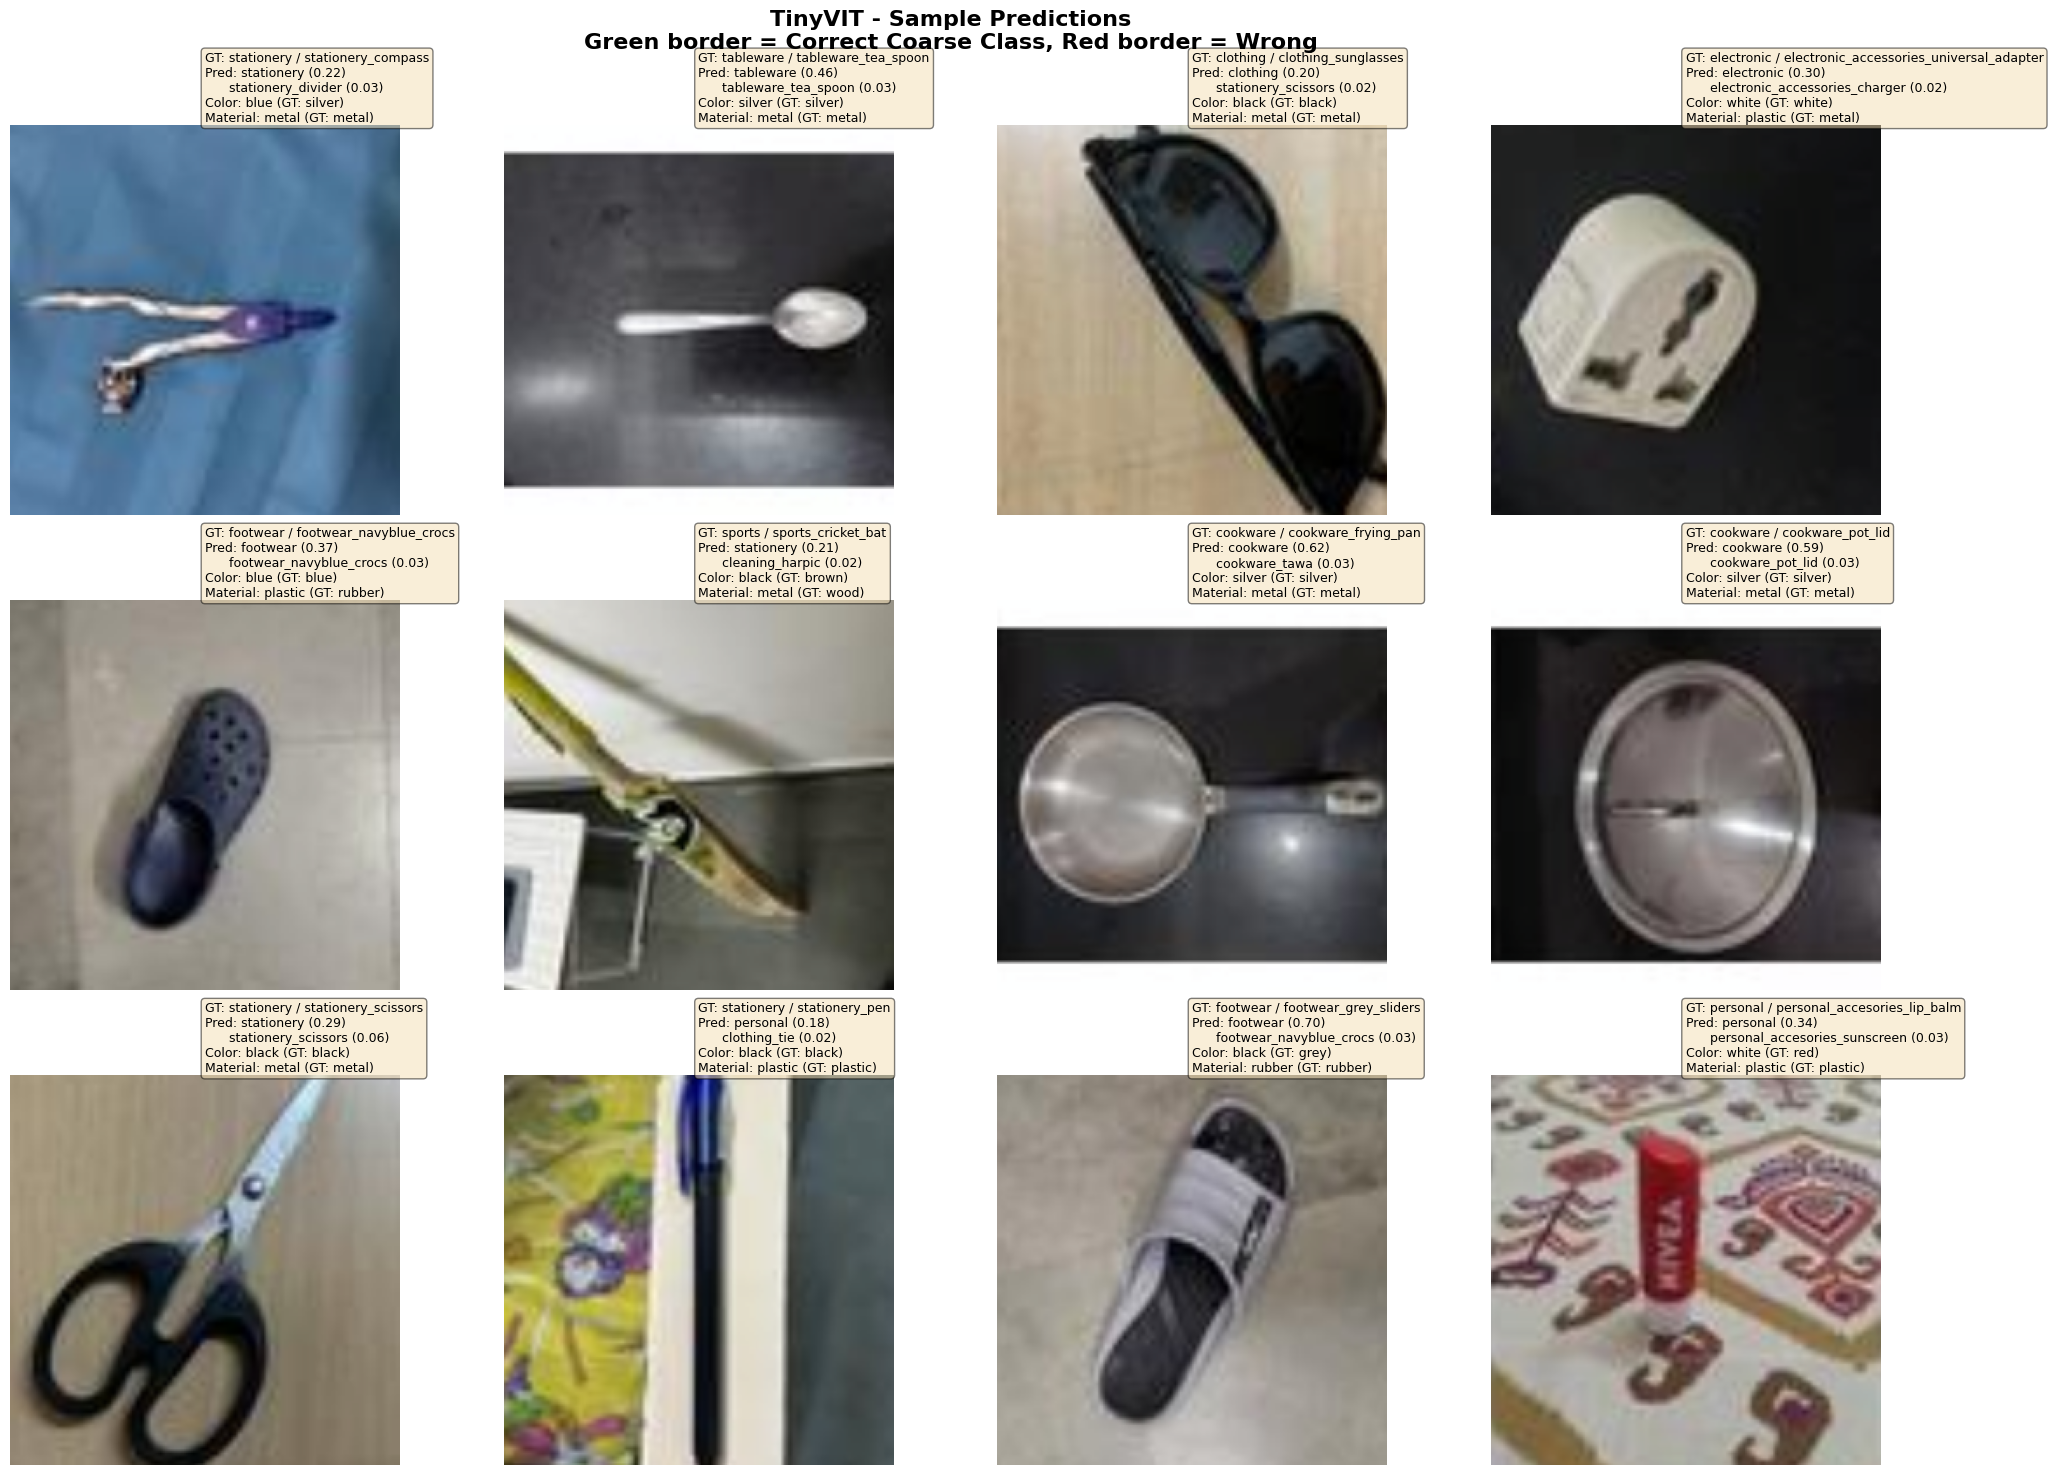

✅ Sample prediction visualizations complete!


In [25]:
# 📊 VISUALIZATION 5: Sample Predictions Grid

print("🎨 Generating sample prediction visualizations...")

import matplotlib.pyplot as plt
from PIL import Image

def visualize_predictions(model, dataset, num_samples=12, model_name="Model"):
    """Visualize model predictions on sample images."""
    model.eval()
    
    # Get random samples
    indices = np.random.choice(len(dataset), size=min(num_samples, len(dataset)), replace=False)
    
    fig, axes = plt.subplots(3, 4, figsize=(20, 15))
    axes = axes.flatten()
    
    for idx, sample_idx in enumerate(indices):
        ax = axes[idx]
        
        # Get sample
        img_tensor, facet_ids, caption, inst_id = dataset[sample_idx]
        
        # Get prediction
        with torch.no_grad():
            img_batch = img_tensor.unsqueeze(0).to(device)
            with torch.cuda.amp.autocast(enabled=(device.type=='cuda')):
                _, logits_attrs, _ = model(img_batch)
        
        # Get ground truth
        gt_coarse = id_to_facet_value_unified['coarse_class'][facet_ids['coarse_class']]
        gt_fine = id_to_facet_value_unified['fine_class'][facet_ids['fine_class']]
        gt_color = id_to_facet_value_unified['color'][facet_ids['color']]
        gt_material = id_to_facet_value_unified['material'][facet_ids['material']]
        
        # Get predictions
        pred_coarse_id = logits_attrs['coarse_class'].argmax(dim=1).item()
        pred_coarse = id_to_facet_value_unified['coarse_class'][pred_coarse_id]
        pred_coarse_conf = torch.softmax(logits_attrs['coarse_class'], dim=1)[0, pred_coarse_id].item()
        
        pred_fine_id = logits_attrs['fine_class'].argmax(dim=1).item()
        pred_fine = id_to_facet_value_unified['fine_class'][pred_fine_id]
        pred_fine_conf = torch.softmax(logits_attrs['fine_class'], dim=1)[0, pred_fine_id].item()
        
        pred_color_id = logits_attrs['color'].argmax(dim=1).item()
        pred_color = id_to_facet_value_unified['color'][pred_color_id]
        
        pred_material_id = logits_attrs['material'].argmax(dim=1).item()
        pred_material = id_to_facet_value_unified['material'][pred_material_id]
        
        # Denormalize image for display
        img_display = img_tensor.cpu().numpy().transpose(1, 2, 0)
        img_display = img_display * np.array([0.229, 0.224, 0.225]) + np.array([0.485, 0.456, 0.406])
        img_display = np.clip(img_display, 0, 1)
        
        # Display image
        ax.imshow(img_display)
        ax.axis('off')
        
        # Create title with predictions
        coarse_color = 'green' if pred_coarse == gt_coarse else 'red'
        fine_color = 'green' if pred_fine == gt_fine else 'red'
        
        title = f"GT: {gt_coarse} / {gt_fine}\n"
        title += f"Pred: {pred_coarse} ({pred_coarse_conf:.2f})\n"
        title += f"      {pred_fine} ({pred_fine_conf:.2f})\n"
        title += f"Color: {pred_color} (GT: {gt_color})\n"
        title += f"Material: {pred_material} (GT: {gt_material})"
        
        ax.set_title(title, fontsize=9, ha='left', va='top', 
                    bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
        
        # Add border color based on correctness
        for spine in ax.spines.values():
            spine.set_edgecolor(coarse_color if pred_coarse == gt_coarse else 'red')
            spine.set_linewidth(3)
    
    plt.suptitle(f'{model_name} - Sample Predictions\nGreen border = Correct Coarse Class, Red border = Wrong', 
                 fontsize=16, fontweight='bold')
    plt.tight_layout()
    plt.show()

# Visualize samples from DeiT
print("\n🖼️  DeiT-Tiny Predictions:")
visualize_predictions(model_unified, test_set_unified, num_samples=12, model_name="DeiT-Tiny")

# Visualize samples from TinyVIT
print("\n🖼️  TinyVIT Predictions:")
visualize_predictions(model_unified_tinyvit, test_set_unified, num_samples=12, model_name="TinyVIT")

print("✅ Sample prediction visualizations complete!")


In [ ]:
# 📊 VISUALIZATION 6: Error Analysis & Misclassification Patterns

print("🎨 Analyzing misclassification patterns...")

import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

def analyze_misclassifications(model, loader, model_name="Model"):
    """Analyze common misclassification patterns."""
    model.eval()
    
    misclass_patterns = {
        'coarse_class': [],  # (true, predicted)
        'fine_class': [],
        'by_confidence': {'low': [], 'medium': [], 'high': []}
    }
    
    all_predictions = {
        'coarse_correct': 0,
        'fine_correct': 0,
        'both_correct': 0,
        'total': 0
    }
    
    with torch.no_grad():
        for images, facet_ids, captions, _ in loader:
            images = images.to(device, non_blocking=True)
            facet_batch = {f: torch.as_tensor([d[f] for d in facet_ids], device=device) for f in FACETS_UNIFIED}
            
            with torch.cuda.amp.autocast(enabled=(device.type=='cuda')):
                _, logits_attrs, _ = model(images)
            
            # Coarse class analysis
            coarse_preds = logits_attrs['coarse_class'].argmax(dim=1)
            coarse_targets = facet_batch['coarse_class']
            coarse_probs = torch.softmax(logits_attrs['coarse_class'], dim=1)
            coarse_conf = coarse_probs.max(dim=1)[0]
            
            # Fine class analysis
            fine_preds = logits_attrs['fine_class'].argmax(dim=1)
            fine_targets = facet_batch['fine_class']
            
            for i in range(len(images)):
                all_predictions['total'] += 1
                coarse_correct = (coarse_preds[i] == coarse_targets[i]).item()
                fine_correct = (fine_preds[i] == fine_targets[i]).item()
                
                if coarse_correct:
                    all_predictions['coarse_correct'] += 1
                if fine_correct:
                    all_predictions['fine_correct'] += 1
                if coarse_correct and fine_correct:
                    all_predictions['both_correct'] += 1
                
                # Track misclassifications
                if not coarse_correct:
                    true_class = id_to_facet_value_unified['coarse_class'][coarse_targets[i].item()]
                    pred_class = id_to_facet_value_unified['coarse_class'][coarse_preds[i].item()]
                    conf = coarse_conf[i].item()
                    
                    misclass_patterns['coarse_class'].append((true_class, pred_class))
                    
                    # Categorize by confidence
                    if conf < 0.5:
                        misclass_patterns['by_confidence']['low'].append((true_class, pred_class, conf))
                    elif conf < 0.8:
                        misclass_patterns['by_confidence']['medium'].append((true_class, pred_class, conf))
                    else:
                        misclass_patterns['by_confidence']['high'].append((true_class, pred_class, conf))
                
                if not fine_correct:
                    true_fine = id_to_facet_value_unified['fine_class'][fine_targets[i].item()]
                    pred_fine = id_to_facet_value_unified['fine_class'][fine_preds[i].item()]
                    misclass_patterns['fine_class'].append((true_fine, pred_fine))
    
    return misclass_patterns, all_predictions

# Analyze both models
misc_deit, stats_deit = analyze_misclassifications(model_unified, test_loader_unified, "DeiT-Tiny")
misc_tiny, stats_tiny = analyze_misclassifications(model_unified_tinyvit, test_loader_unified, "TinyVIT")

# Visualization 1: Most Common Misclassification Pairs
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# DeiT misclassifications
ax = axes[0]
counter_deit = Counter(misc_deit['coarse_class'])
if counter_deit:
    top_10 = counter_deit.most_common(10)
    labels = [f"{true} → {pred}" for (true, pred), count in top_10]
    counts = [count for _, count in top_10]
    
    bars = ax.barh(range(len(labels)), counts, color='#e74c3c', alpha=0.7)
    ax.set_yticks(range(len(labels)))
    ax.set_yticklabels(labels, fontsize=10)
    ax.set_xlabel('Frequency', fontsize=12, fontweight='bold')
    ax.set_title(f'DeiT-Tiny: Top 10 Misclassification Pairs\n(Coarse Class)', 
                fontsize=13, fontweight='bold')
    ax.grid(axis='x', alpha=0.3)
    
    # Add count labels
    for i, (bar, count) in enumerate(zip(bars, counts)):
        ax.text(count + 0.1, i, str(count), va='center', fontsize=9)

# TinyVIT misclassifications
ax = axes[1]
counter_tiny = Counter(misc_tiny['coarse_class'])
if counter_tiny:
    top_10 = counter_tiny.most_common(10)
    labels = [f"{true} → {pred}" for (true, pred), count in top_10]
    counts = [count for _, count in top_10]
    
    bars = ax.barh(range(len(labels)), counts, color='#9b59b6', alpha=0.7)
    ax.set_yticks(range(len(labels)))
    ax.set_yticklabels(labels, fontsize=10)
    ax.set_xlabel('Frequency', fontsize=12, fontweight='bold')
    ax.set_title(f'TinyVIT: Top 10 Misclassification Pairs\n(Coarse Class)', 
                fontsize=13, fontweight='bold')
    ax.grid(axis='x', alpha=0.3)
    
    # Add count labels
    for i, (bar, count) in enumerate(zip(bars, counts)):
        ax.text(count + 0.1, i, str(count), va='center', fontsize=9)

plt.tight_layout()
plt.show()

# Visualization 2: Hierarchical Consistency Analysis
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# DeiT
ax = axes[0]
categories = ['Both\nCorrect', 'Coarse Only\nCorrect', 'Fine Only\nCorrect', 'Both\nWrong']
deit_values = [
    stats_deit['both_correct'],
    stats_deit['coarse_correct'] - stats_deit['both_correct'],
    stats_deit['fine_correct'] - stats_deit['both_correct'],
    stats_deit['total'] - stats_deit['coarse_correct'] - stats_deit['fine_correct'] + stats_deit['both_correct']
]
colors = ['#2ecc71', '#3498db', '#f39c12', '#e74c3c']

bars = ax.bar(categories, deit_values, color=colors, alpha=0.7, edgecolor='black', linewidth=1.5)
ax.set_ylabel('Number of Samples', fontsize=12, fontweight='bold')
ax.set_title('DeiT-Tiny: Hierarchical Prediction Patterns', fontsize=13, fontweight='bold')
ax.grid(axis='y', alpha=0.3)

for bar, val in zip(bars, deit_values):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height + 1,
            f'{val}\n({val/stats_deit["total"]*100:.1f}%)',
            ha='center', va='bottom', fontsize=10, fontweight='bold')

# TinyVIT
ax = axes[1]
tiny_values = [
    stats_tiny['both_correct'],
    stats_tiny['coarse_correct'] - stats_tiny['both_correct'],
    stats_tiny['fine_correct'] - stats_tiny['both_correct'],
    stats_tiny['total'] - stats_tiny['coarse_correct'] - stats_tiny['fine_correct'] + stats_tiny['both_correct']
]

bars = ax.bar(categories, tiny_values, color=colors, alpha=0.7, edgecolor='black', linewidth=1.5)
ax.set_ylabel('Number of Samples', fontsize=12, fontweight='bold')
ax.set_title('TinyVIT: Hierarchical Prediction Patterns', fontsize=13, fontweight='bold')
ax.grid(axis='y', alpha=0.3)

for bar, val in zip(bars, tiny_values):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height + 1,
            f'{val}\n({val/stats_tiny["total"]*100:.1f}%)',
            ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

# Visualization 3: Error Rate by Confidence
fig, ax = plt.subplots(figsize=(12, 6))

conf_categories = ['Low\n(<0.5)', 'Medium\n(0.5-0.8)', 'High\n(>0.8)']
deit_errors = [
    len(misc_deit['by_confidence']['low']),
    len(misc_deit['by_confidence']['medium']),
    len(misc_deit['by_confidence']['high'])
]
tiny_errors = [
    len(misc_tiny['by_confidence']['low']),
    len(misc_tiny['by_confidence']['medium']),
    len(misc_tiny['by_confidence']['high'])
]

x = np.arange(len(conf_categories))
width = 0.35

bars1 = ax.bar(x - width/2, deit_errors, width, label='DeiT-Tiny', color='#3498db', alpha=0.8)
bars2 = ax.bar(x + width/2, tiny_errors, width, label='TinyVIT', color='#e74c3c', alpha=0.8)

ax.set_xlabel('Confidence Level', fontsize=12, fontweight='bold')
ax.set_ylabel('Number of Errors', fontsize=12, fontweight='bold')
ax.set_title('Misclassification Count by Confidence Level\n(Coarse Class)', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(conf_categories)
ax.legend(fontsize=11)
ax.grid(axis='y', alpha=0.3)

for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        if height > 0:
            ax.text(bar.get_x() + bar.get_width()/2., height + 0.3,
                    f'{int(height)}', ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()

print("✅ Error analysis complete!")
print(f"\n📊 DeiT-Tiny Error Summary:")
print(f"   Coarse accuracy: {stats_deit['coarse_correct']/stats_deit['total']:.2%}")
print(f"   Fine accuracy: {stats_deit['fine_correct']/stats_deit['total']:.2%}")
print(f"   Both correct: {stats_deit['both_correct']/stats_deit['total']:.2%}")
print(f"   High-confidence errors: {len(misc_deit['by_confidence']['high'])}")

print(f"\n📊 TinyVIT Error Summary:")
print(f"   Coarse accuracy: {stats_tiny['coarse_correct']/stats_tiny['total']:.2%}")
print(f"   Fine accuracy: {stats_tiny['fine_correct']/stats_tiny['total']:.2%}")
print(f"   Both correct: {stats_tiny['both_correct']/stats_tiny['total']:.2%}")
print(f"   High-confidence errors: {len(misc_tiny['by_confidence']['high'])}")
